<center><p float="center">
  <img src="https://upload.wikimedia.org/wikipedia/commons/e/e9/4_RGB_McCombs_School_Brand_Branded.png" width="300" height="100"/>
  <img src="https://mma.prnewswire.com/media/1458111/Great_Learning_Logo.jpg?p=facebook" width="200" height="100"/>
</p></center>

<center><font size=10>Artificial Intelligence and Machine Learning</center></font>
<center><font size=6>Week 2: Optimizing Neural Networks</center></font>

<center><p float="center">
  <img src="https://images.pexels.com/photos/6994265/pexels-photo-6994265.jpeg" width=720></a>
<center><font size=6>Credit Card Fraud Detection</center></font>

## Problem Statement

### Business Context

In the rapidly evolving digital financial landscape, the ability to detect fraudulent credit card transactions has become vital for minimizing financial losses and maintaining customer trust. With the significant increase in digital payment volumes, traditional rule-based detection systems often struggle to keep pace with increasingly sophisticated and adaptive fraud techniques employed by malicious actors. This inadequacy leads to the potential for substantial economic damage to financial institutions and a degradation of customer confidence.

To address this pressing issue, financial institutions are increasingly turning to deep learning models that can analyze a variety of transaction features, including distance from the customer’s home, spending patterns, and device usage behaviors. By leveraging these models, banks and financial service providers can facilitate real-time fraud detection, enhance their risk management strategies, and build a more resilient security framework. This proactive approach allows institutions to respond swiftly to potential fraud, effectively shielding both their assets and their customers from financial harm.

### Objective

The challenge at hand is to develop an effective deep learning model capable of accurately detecting fraudulent transactions amidst the complexities of transactional data. The objective is to create a system that can classify transactions as either genuine or fraudulent by utilizing various behavioral and transactional features to inform its predictions.

The end goal of the project is to fortify the bank's defenses against fraud, fostering a secure and trustworthy environment for customers while preserving the institution's long-term viability and reputation in the competitive financial landscape.

### Data Description

This dataset contains transaction details for fraud detection, with the following columns:

- **distance_from_home**: Distance between transaction location and the customer’s home.
- **distance_from_last_transaction**: Distance from the customer’s last transaction.
- **ratio_to_median_purchase_price**: Ratio of the current transaction to the customer's median purchase price.
- **repeat_retailer**: Indicates if the retailer is one the customer has visited before.
- **used_chip**: Flag indicating whether the card chip was used.
- **used_pin_number**: Flag indicating whether a PIN was used.
- **online_order**: Flag indicating if the transaction was made online.
- **fraud**: Target variable; indicates if the transaction was fraudulent (1) or not (0).

This dataset will help build a model to detect potentially fraudulent transactions.

## Installing and Importing necessary libraries

In [ ]:
# Installing the libraries with the specified version
!pip install --no-deps tensorflow==2.19.0 scikit-learn==1.6.1 matplotlib==3.10.0 seaborn==0.13.2 numpy==2.0.2 pandas==2.2.2 -q --user --no-warn-script-location

**Note**:
- After running the above cell, kindly restart the runtime (for Google Colab) or notebook kernel (for Jupyter Notebook), and run all cells sequentially from the next cell.
- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in ***this notebook***.

In [ ]:
# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd
import time

# Libraries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 200)

# to split the data into train and test
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# Import MinMaxScaler for feature scaling.
from sklearn.preprocessing import MinMaxScaler

import tensorflow as tf #An end-to-end open source machine learning platform
from tensorflow import keras  # High-level neural networks API for deep learning.
from keras import backend   # Abstraction layer for neural network backend engines.
from keras.models import Sequential  # Model for building NN sequentially.
from keras.layers import Dense, Dropout, BatchNormalization, Input

# to suppress warnings
import warnings
warnings.filterwarnings("ignore")

In [ ]:
# Set the seed using keras.utils.set_random_seed. This will set:
# 1) `numpy` seed
# 2) backend random seed
# 3) `python` random seed
keras.utils.set_random_seed(812)

# If using TensorFlow, this will make GPU ops as deterministic as possible,
# but it will affect the overall performance, so be mindful of that.
tf.config.experimental.enable_op_determinism()

## Loading the dataset

In [ ]:
# uncomment and run the following lines in case Google Colab is being used
# from google.colab import drive
# drive.mount('/content/drive')

In [ ]:
# loading the dataset
data = pd.read_csv("fraud_dataset.csv")

## Data Overview

Now that the dataset is loaded, the next step is to understand what the data looks like. Before we move on to building models, it’s important to take a closer look at the structure and contents of the dataset.

In this step, we will:

- Check how many rows and columns the dataset has  
- Look at the first few rows to get a feel for the data  
- See what data types each column has  
- Check for any missing or unusual values  

This basic overview will help us decide what kind of cleaning or preparation the data might need. Let’s explore the dataset and understand what we’re working with.

### Displaying the first few rows of the dataset

In [ ]:
data.head(10)

,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud
0,4.597583,0.084182,0.964720,1,0,0,0,0
1,2.847323,2.212334,0.203593,1,0,0,1,0
2,4.248422,5.191844,0.247123,1,1,1,1,0
3,8.495267,0.194119,0.361700,1,1,0,1,0
4,38.473389,0.746505,3.119982,1,0,0,1,0
5,15.632878,12.065805,2.327001,1,0,0,1,0
6,36.471617,0.416918,0.370543,1,0,0,1,0
7,26.390598,0.618949,0.943148,1,0,0,1,0
8,30.623331,37.642254,0.922867,1,0,0,0,0
9,37.701224,8.210105,0.698312,1,0,0,1,0


### Displaying the last few rows of the dataset

In [ ]:
data.tail(10)


,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud
152730,13.793593,1.376635,0.149236,1,0,0,1,0
152731,31.695666,8.489614,0.686936,1,1,0,0,0
152732,4.387251,0.153863,0.842752,1,1,0,1,0
152733,12.304705,0.723287,1.064707,1,0,0,0,0
152734,41.438062,0.154841,1.312763,1,0,0,1,0
152735,6.315519,1.925504,2.407671,1,0,0,0,0
152736,8.981446,5.338373,0.269774,1,1,0,1,0
152737,6.051465,0.034045,0.275358,1,1,0,1,0
152738,12.158849,4.682585,4.491612,1,0,0,1,1
152739,28.347824,5.517715,0.713750,1,0,0,1,0


### Checking the shape of the dataset

In [ ]:
data.shape


(152740, 8)

The data consists of 152740 rows and 8 columns

### Checking the data types of the columns of the dataset

In [ ]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 152740 entries, 0 to 152739
Data columns (total 8 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   distance_from_home              152740 non-null  float64
 1   distance_from_last_transaction  152740 non-null  float64
 2   ratio_to_median_purchase_price  152740 non-null  float64
 3   repeat_retailer                 152740 non-null  int64  
 4   used_chip                       152740 non-null  int64  
 5   used_pin_number                 152740 non-null  int64  
 6   online_order                    152740 non-null  int64  
 7   fraud                           152740 non-null  int64  
dtypes: float64(3), int64(5)
memory usage: 9.3 MB


The data contains 152,740 records with 8 features and no missing values.

### Checking for missing values

In [ ]:
data.isna().sum()

,0
distance_from_home,0
distance_from_last_transaction,0
ratio_to_median_purchase_price,0
repeat_retailer,0
used_chip,0
used_pin_number,0
online_order,0
fraud,0


We conclude there are no missing rows in the DataFrame as all columns have 152,740 non-null entries, matching the total number of records.


### Checking statistical summary

In [ ]:
data.describe()


,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud
count,152740.000000,152740.000000,152740.000000,152740.000000,152740.000000,152740.000000,152740.000000,152740.000000
mean,25.466747,4.743427,1.696707,0.881917,0.353830,0.105002,0.642373,0.057221
std,64.714307,24.151898,2.562895,0.322707,0.478159,0.306557,0.479303,0.232266
min,0.024602,0.000118,0.006125,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.859140,0.293324,0.467232,1.000000,0.000000,0.000000,0.000000,0.000000
50%,9.852958,0.989281,0.971711,1.000000,0.000000,0.000000,1.000000,0.000000
75%,25.304466,3.310223,1.985643,1.000000,1.000000,0.000000,1.000000,0.000000
max,8777.136420,4968.315477,91.847397,1.000000,1.000000,1.000000,1.000000,1.000000


Note: To make the visualization easier to interpret, we can also transpose the data by appending `.T` at the end.

In [ ]:
data.describe().T


,count,mean,std,min,25%,50%,75%,max
distance_from_home,152740.0,25.466747,64.714307,0.024602,3.859140,9.852958,25.304466,8777.136420
distance_from_last_transaction,152740.0,4.743427,24.151898,0.000118,0.293324,0.989281,3.310223,4968.315477
ratio_to_median_purchase_price,152740.0,1.696707,2.562895,0.006125,0.467232,0.971711,1.985643,91.847397
repeat_retailer,152740.0,0.881917,0.322707,0.000000,1.000000,1.000000,1.000000,1.000000
used_chip,152740.0,0.353830,0.478159,0.000000,0.000000,0.000000,1.000000,1.000000
used_pin_number,152740.0,0.105002,0.306557,0.000000,0.000000,0.000000,0.000000,1.000000
online_order,152740.0,0.642373,0.479303,0.000000,0.000000,1.000000,1.000000,1.000000
fraud,152740.0,0.057221,0.232266,0.000000,0.000000,0.000000,0.000000,1.000000


* **`distance_from_home`**: Mean = 25.47, Std = 64.71, ranging from 0.02 to 8777.14, indicating wide variation in how far customers are from home when making purchases.
* **`distance_from_last_transaction`**: Mean = 4.74, Std = 24.15, ranging from 0.0001 to 4968.32, suggesting diverse distances between consecutive transactions.
* **`ratio_to_median_purchase_price`**: Mean = 1.70, Std = 2.56, with a range from 0.006 to 91.85, indicating that most purchases are close to the median price, though some outliers exist.

The last five columns (**`repeat_retailer`**, **`used_chip`**, **`used_pin_number`**, **`online_order`**, and **`fraud`**) are binary categorical variables (0 or 1), representing transaction characteristics such as repeat retailer usage, chip usage, PIN entry, online purchase, and whether the transaction was fraudulent.


### Checking for duplicate values

In [ ]:
# Check for duplicate rows
duplicate_rows = data[data.duplicated()]

# Print the number of duplicate rows
print(f"Number of duplicate rows: {len(duplicate_rows)}")


Number of duplicate rows: 0


There are no duplicate records in the data. If any were present, they could be removed using `data.drop_duplicates()`.

In [ ]:
data['fraud'].value_counts()

,count
fraud,
0,144000
1,8740


In [ ]:
data['fraud'].value_counts(normalize=True)

,proportion
fraud,
0,0.942779
1,0.057221


The dataset shows a severe imbalance, with 144,000 non-fraudulent records (94.28%) and only 8,740 fraudulent records (5.72%). This high imbalance will likely require special handling for model training.

## Exploratory Data Analysis

**Note: The EDA section has been covered in detail in the previous case studies. In this case study, we will mainly focus on the model building aspects.**

**The below functions need to be defined to carry out the Exploratory Data Analysis.**

In [ ]:
# function to create labeled barplots


def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 1, 5))
    else:
        plt.figure(figsize=(n + 1, 5))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n].sort_values(),
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

In [ ]:
# function to plot a boxplot and a histogram along the same scale.


def histogram_boxplot(data, feature, figsize=(12, 7), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (12,7))
    kde: whether to the show density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a star will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins, palette="winter"
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

In [ ]:
def labeled_boxplot(df, x_col, y_col, title, x_label, y_label):
    """Generates a box plot with customizable data and labels."""

    # Simple check for necessary columns
    if x_col not in df.columns or y_col not in df.columns:
        print(f"Error: Columns '{x_col}' or '{y_col}' not found in the DataFrame.")
        return

    plt.figure(figsize=(8, 6))

    sns.boxplot(
        x=x_col,
        y=y_col,
        data=df
    )

    plt.title(title)
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.show()

In [ ]:
def filtered_countplot(df, filter_col, filter_val, count_col, title, x_label, y_label):
    """
    Filters a DataFrame and creates a count plot (bar chart) for a specified column.

    Parameters:
    df (pd.DataFrame): The input DataFrame.
    filter_col (str): The column used to filter the data (e.g., 'fraud').
    filter_val (int/str): The value used for filtering (e.g., 1).
    count_col (str): The column to be counted and plotted on the x-axis (e.g., 'online_order').
    title (str): The title of the plot.
    x_label (str): The label for the x-axis.
    y_label (str): The label for the y-axis.
    """

    # Check for required columns
    required_cols = [filter_col, count_col]
    if not all(col in df.columns for col in required_cols):
        print(f"Error: DataFrame is missing one or more required columns: {required_cols}")
        return

    # Filter the DataFrame
    filtered_df = df[df[filter_col] == filter_val]

    # Create the bar chart (countplot)
    plt.figure(figsize=(8, 6))
    sns.countplot(x=count_col, data=filtered_df)

    # Set labels and title
    plt.title(title)
    plt.xlabel(x_label)
    plt.ylabel(y_label)

    plt.show()

In [ ]:
df1 = data.copy()

### Univariate Analysis

#### Numerical Columns

##### `distance_from_home`

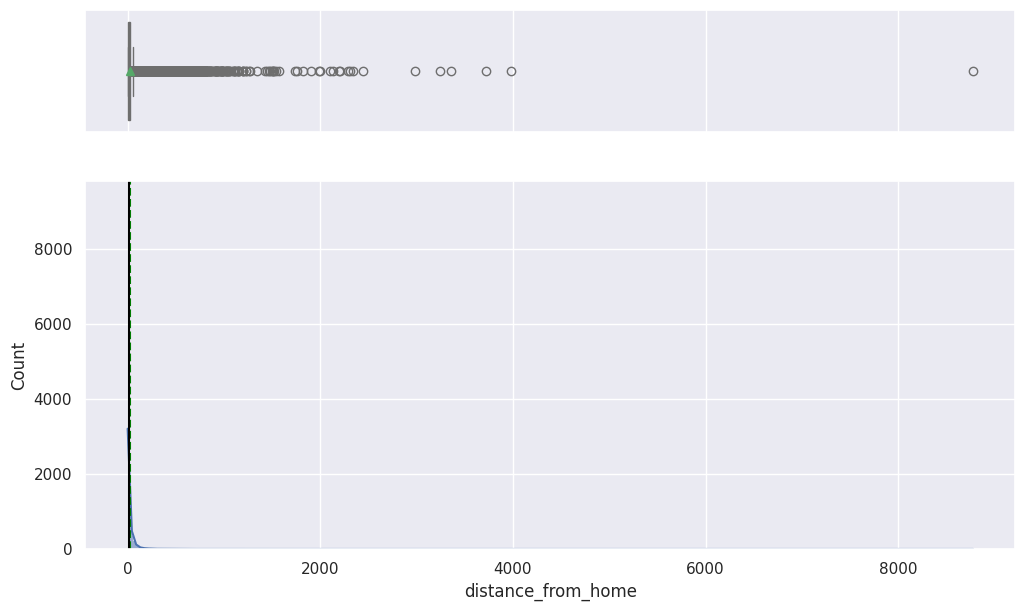

In [ ]:
histogram_boxplot(df1, "distance_from_home", kde=True)

**Observations**
- The distribution is heavily right-skewed (positively skewed).
- The vast majority of transactions have a very small distance from home, clustered close to 0 on the x-axis.
- While rare, some transactions occur at extremely large distances from the customer's home (reaching up to 8,000 or more).

##### `distance_from_last_transaction`

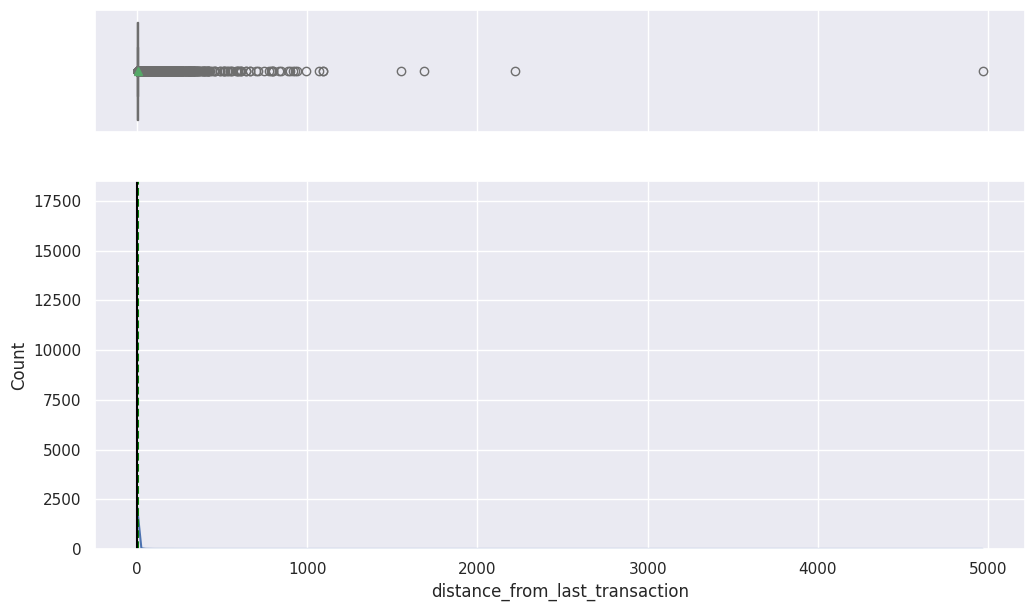

In [ ]:
histogram_boxplot(df1, "distance_from_last_transaction", kde=True)

**Observations**
- Similar to `distance_from_home`, this variable is also extremely right-skewed (positively skewed).
- The majority of transactions are immediately close to the last one.
- While most transactions are close to the last one, there are significant instances where a transaction occurs a very long distance away from the previous location. There are a large number of outliers in this distribution.

##### `ratio_to_median_purchase_price`

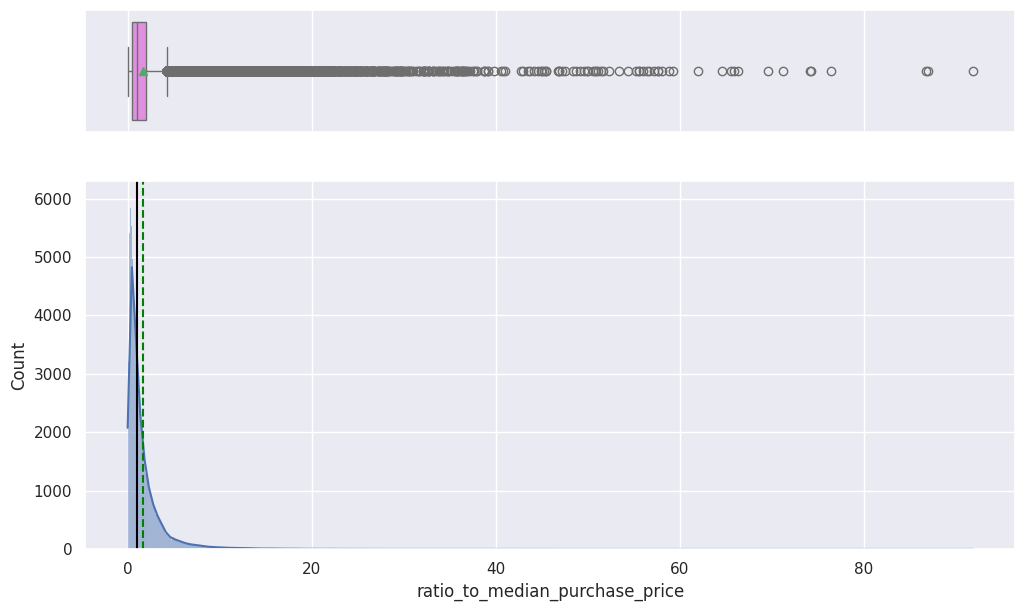

In [ ]:
histogram_boxplot(df1, "ratio_to_median_purchase_price", kde=True)

**Observations**
- This variable is also extremely right-skewed (positively skewed), similar to the distance variable.
- The vertical green dashed line, which represents the mean, is slightly to the right of the mode, confirming the positive skew.
- There is a long tail extending far to the right, indicating that some transactions are many times larger than the customer's typical (median) purchase price (reaching ratios of 80 or more).
- The box itself is very narrow, indicating that the Interquartile Range (IQR) is small. This means 75% of the data (the transactions that are considered "normal" purchases) are closely grouped around the typical ratio of 1.0.

From these charts, we can see that there are many outliers, and some distances are excessively far from the median. This indicates potential irregularities in transaction behavior that may warrant further investigation for fraud.

#### Categorical Columns

##### `repeat_retailer`

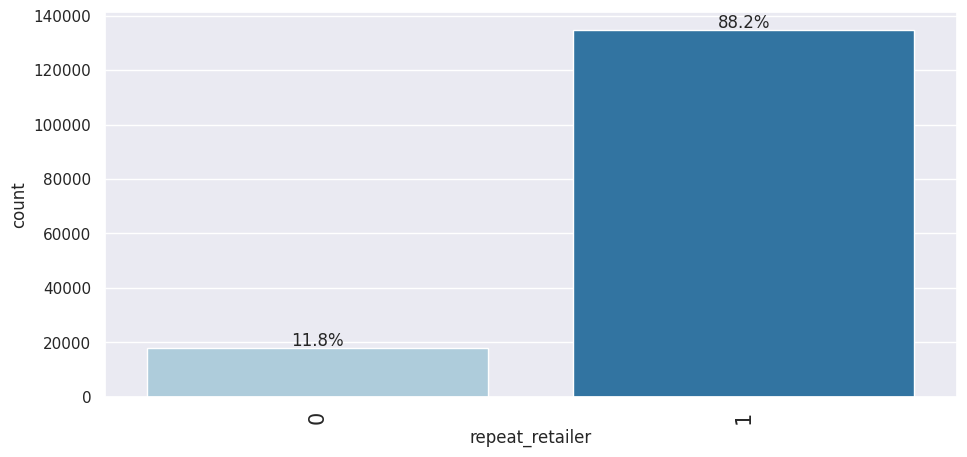

In [ ]:
labeled_barplot(df1, "repeat_retailer", perc=True, n=10)

**Observations**
- The vast majority of transactions, 88.2%, occurred at a retailer the customer has visited before.
- The variable is highly imbalanced, with the 'repeat' category being nearly 8 times more frequent than the 'new' category.
- Since the data is heavily skewed towards `repeat_retailer` = 1, the minority class, `repeat_retailer` = 0 (new retailer), might be an important signal when analyzing potential fraud.

##### `used_chip`

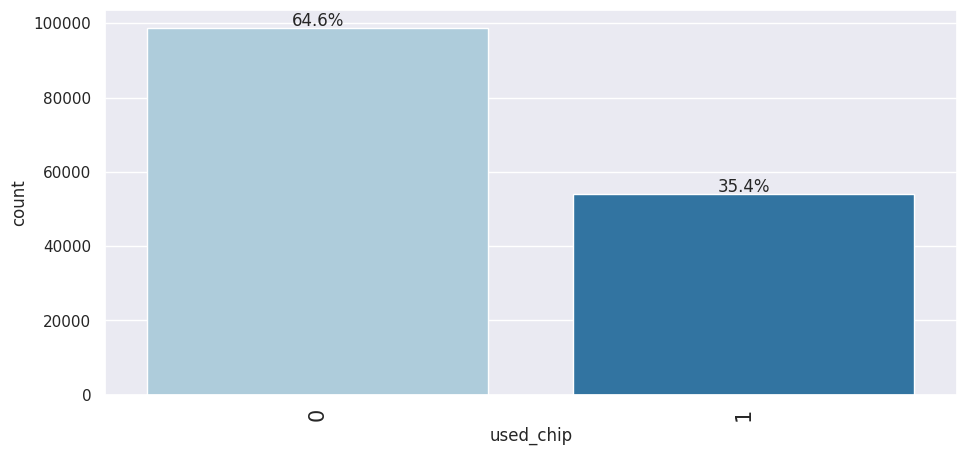

In [ ]:
labeled_barplot(df1, "used_chip", perc=True, n=10)

**Observations**
- The majority of transactions, 64.6%, did not use the card chip. 35.4% of transactions utilized the card chip.
- Transactions where the chip was not used are almost twice as frequent as those where it was.
- Further Bivariate analysis is required for more insight.

##### `used_pin_number`

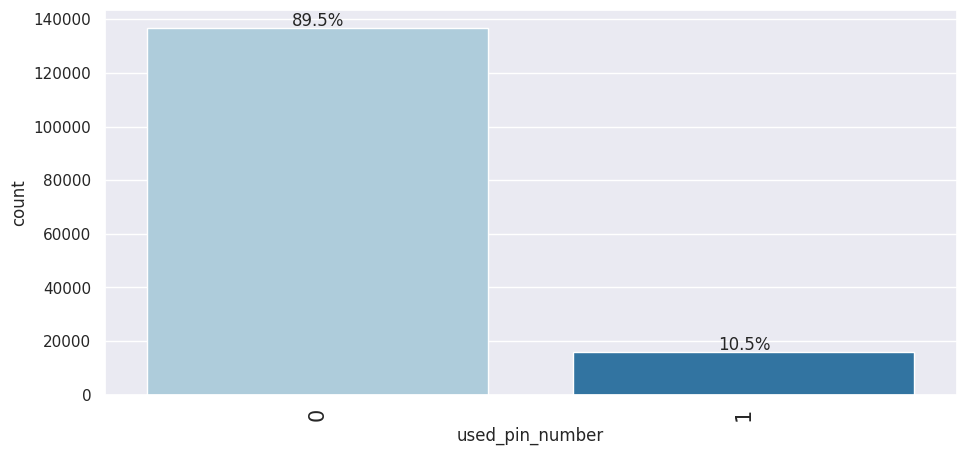

In [ ]:
labeled_barplot(df1, "used_pin_number", perc=True, n=10)

**Observations**
- The vast majority of transactions, 89.5%, did not require or use a PIN. Only 10.5% of transactions utilized a PIN number.
- The variable is highly imbalanced, with the 'PIN not used' category being almost 9 times more frequent than the 'PIN used' category.
- Further bivariate analysis comparing `used_pin_number` against fraud would be necessary to understand if PIN usage is a significant protective factor against fraudulent transactions.

##### `online_order`

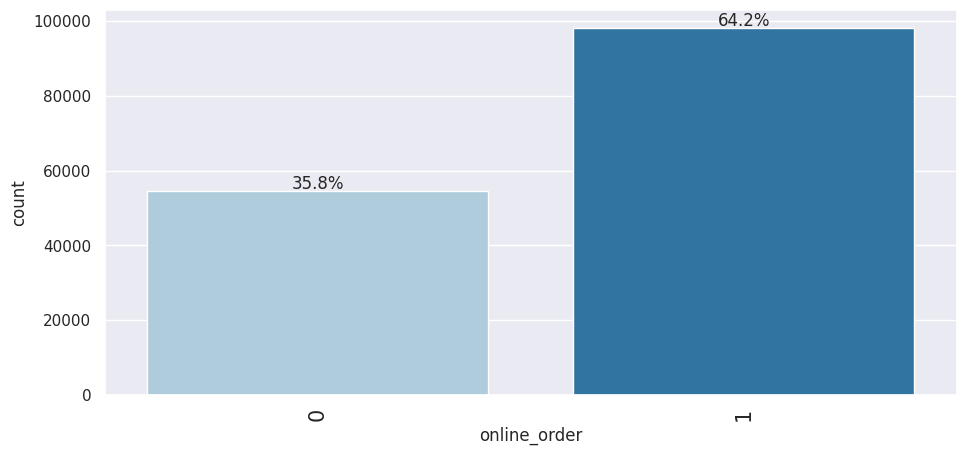

In [ ]:
labeled_barplot(df1, "online_order", perc=True, n=10)

**Observations**
- The majority of transactions, 64.2%, were made online. 35.8% of transactions were not made online
- The variable is moderately imbalanced, with online orders being almost twice as frequent as non-online orders.
- The bivariate analysis (comparing `online_order` vs. `fraud`) will be crucial to see if the proportion of `fraud` is higher in the `online_order` = 1 category compared to the `online_order` = 0 category.

##### `fraud`

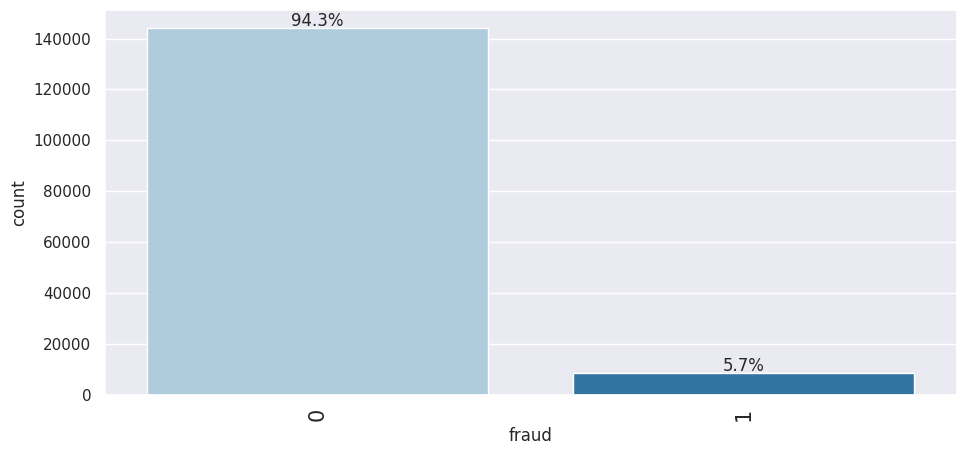

In [ ]:
labeled_barplot(df1, "fraud", perc=True, n=10)

**Observations**
- Non-Fraud (0): The vast majority of transactions, 94.3%, are not fraudulent.
- Fraud (1): Only 5.7% of transactions are classified as fraudulent.
- This dataset exhibits severe class imbalance. The non-fraud class is approximately 16.5 times larger than the fraud class.
- When building a fraud detection model, this imbalance is the most significant challenge. A naive model that simply predicts "Not Fraud" for every transaction would achieve an accuracy of 94.3%, but it would be useless as it would never detect actual fraud.

### Bivariate Analysis

##### Correlation Check

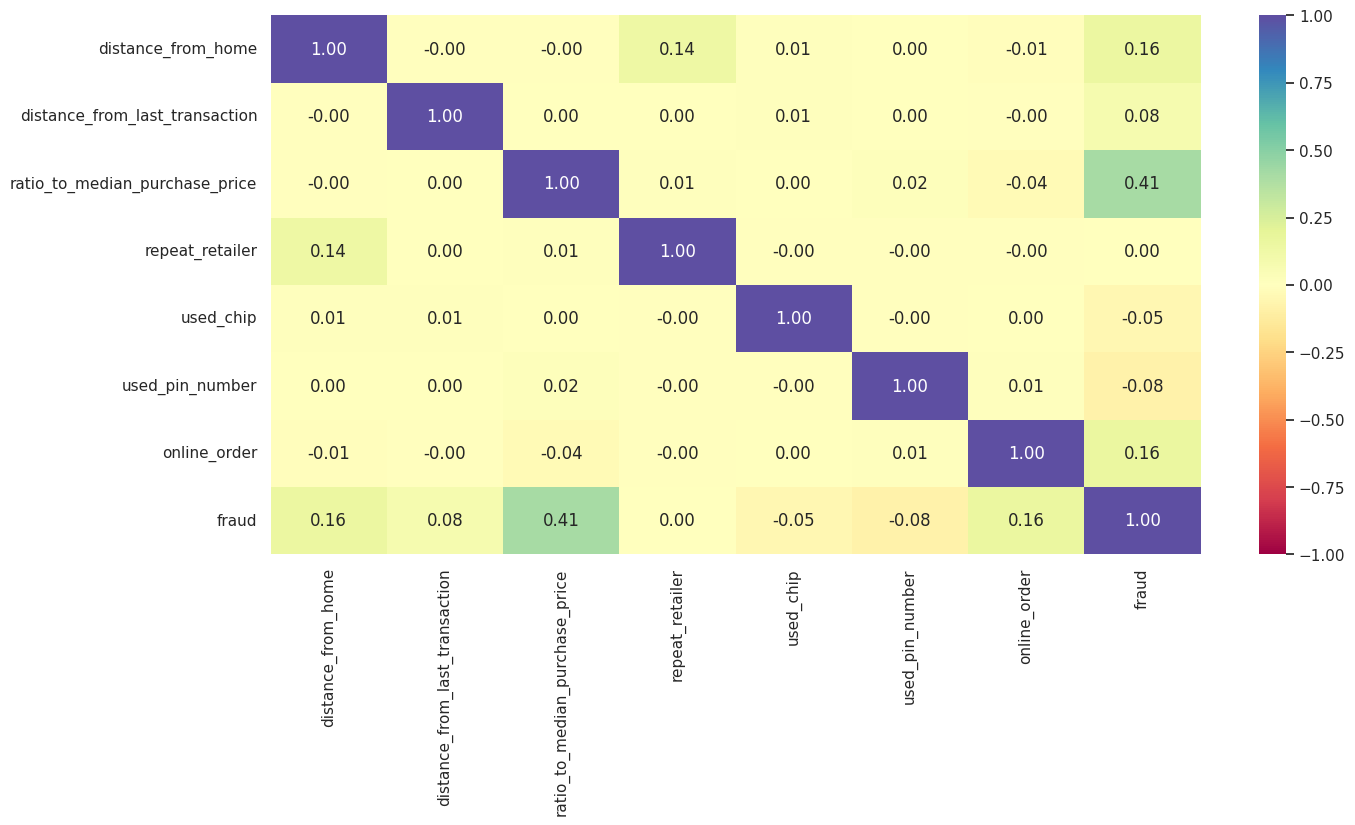

In [ ]:
plt.figure(figsize=(15, 7))
sns.heatmap(
    df1.corr(numeric_only = True), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral"
)
plt.show()

**Observations**

**High Positive Correlation**
- The variable `ratio_to_median_purchase_price` has the highest positive correlation with `fraud` (0.41), suggesting that fraudulent transactions tend to have purchase prices significantly higher than the median for that category.

**Medium Positive Correlation**
- `online_order` (r=0.16): Being an online order is moderately positively correlated with fraud, meaning online transactions are more likely to be fraudulent.
- `distance_from_home` (r=0.16): A larger distance from home is moderately positively correlated with fraud.
- `distance_from_last_transaction` (r=0.08): A larger distance from the last transaction has a weaker, but still positive, correlation with fraud


**No/Weak Correlation**

- `repeat_retailer` (r=0.00): Whether the retailer is a repeat one has virtually no linear correlation with fraud, meaning it is likely a poor predictor.

**Negative Correlation**

- `used_chip` (r= −0.05): This correlation is very weak; slightly negative, suggesting chip usage has a weak but definite protective effect against fraud.

- `used_pin_number` (r= −0.08): This is a weak negative correlation, suggesting that using a PIN has a weak but definite protective effect against fraud.

**Strongest Inter-Variable Correlation:**
- There is a weak positive correlation of 0.14 between `distance_from_home` and `repeat_retailer`. This suggests that as the distance from home increases slightly, the transaction is slightly more likely to be with a repeat retailer.

**Negligible/Very Weak Inter-Variable Correlations:**
- Most continuous variables (like `distance_from_home`, `distance_from_last_transaction`, and `ratio_to_median_purchase_price`) have correlations very close to 0.00 with each other and with the binary features. This is a good finding for modeling, as it indicates a low degree of multicollinearity.

##### `fraud` vs `distance_from_home`

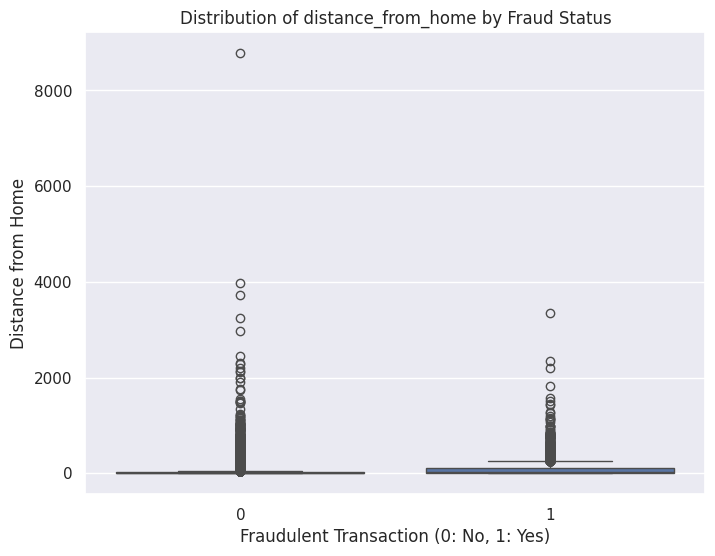

In [ ]:
labeled_boxplot(df=df1,
                x_col='fraud',
                y_col='distance_from_home',
                title='Distribution of distance_from_home by Fraud Status',
                x_label='Fraudulent Transaction (0: No, 1: Yes)',
                y_label='Distance from Home')

**Observations**
- For both fraudulent (1) and non-fraudulent (0) transactions, the distribution is extremely right-skewed and concentrated near zero.
- Fraudulent (1) Transactions: The box and median appear to be slightly higher (further from zero) than the non-fraudulent (0) transactions. This suggests that the typical fraudulent transaction happens at a marginally greater distance from the last transaction than the typical non-fraudulent transaction.


##### `fraud` vs `distance_from_last_transaction`

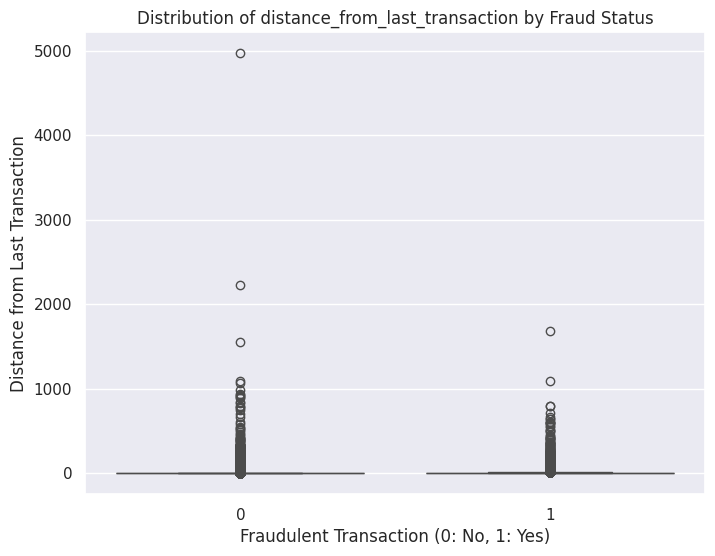

In [ ]:
labeled_boxplot(
    df=df1,
    x_col='fraud',
    y_col='distance_from_last_transaction',
    title='Distribution of distance_from_last_transaction by Fraud Status',
    x_label='Fraudulent Transaction (0: No, 1: Yes)',
    y_label='Distance from Last Transaction'
)

**Observations**

- Both non-fraudulent (0) and fraudulent (1) transactions are highly right-skewed and concentrated near zero.

- The median (line inside the box) and quartiles (box edges) for both groups are extremely close to zero, meaning most transactions are local, regardless of fraud status.



##### `fraud` vs `ratio_to_median_purchase_price`

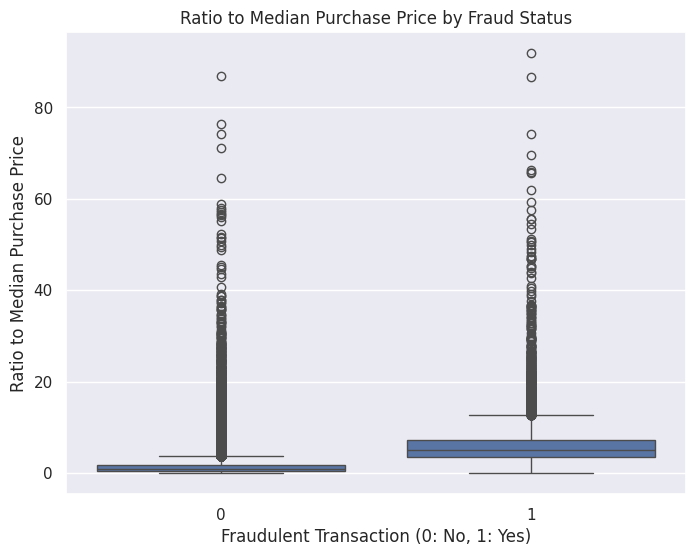

In [ ]:
labeled_boxplot(
    df=df1,
    x_col='fraud',
    y_col='ratio_to_median_purchase_price',
    title='Ratio to Median Purchase Price by Fraud Status',
    x_label='Fraudulent Transaction (0: No, 1: Yes)',
    y_label='Ratio to Median Purchase Price'
)

**Observations**

- There is clear separation between the central 50% (the box) of the two classes. If a transaction has a ratio greater than about 2.0 (the maximum Q3 for non-fraud), it is significantly more likely to be fraud.
- This visualization is the most informative so far, confirming the highest positive correlation (r=0.41) with fraud.

##### `fraud` vs `used_chip`

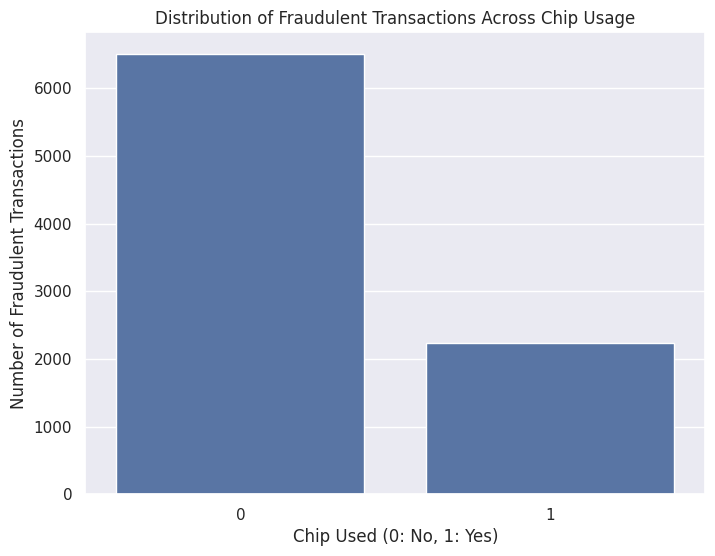

In [ ]:
filtered_countplot(
    df=df1,
    filter_col='fraud',
    filter_val=1,
    count_col='used_chip',
    title='Distribution of Fraudulent Transactions Across Chip Usage',
    x_label='Chip Used (0: No, 1: Yes)',
    y_label='Number of Fraudulent Transactions'
)

**Observation**

- Chip Not Used (0): The number of fraudulent transactions is significantly higher where the chip was not used, totaling approximately 6,500 cases.

- Chip Used (1): The number of fraudulent transactions where the chip was used is much lower, totaling approximately 2,200 cases.

- There are nearly three times as many absolute fraud cases in the non-chip category compared to the chip-used category (6,500/2,200≈2.95).

- This suggests that the use of a chip acts as a powerful deterrent or security measure

##### `fraud` vs `online_order`

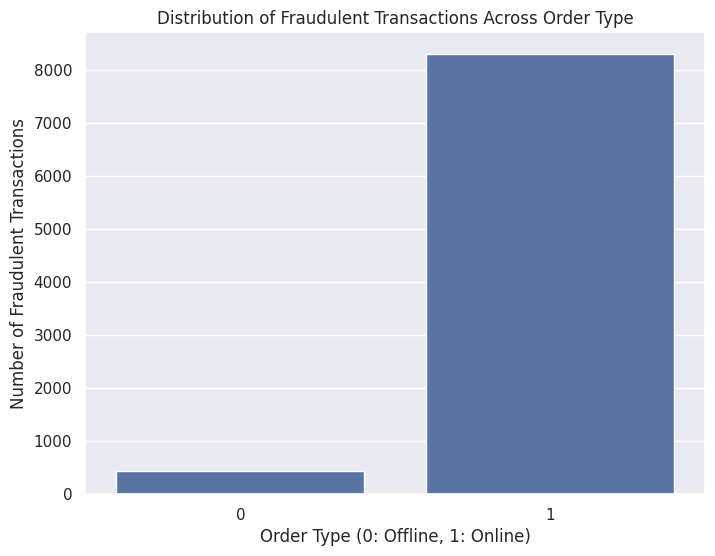

In [ ]:
filtered_countplot(
    df=df1,
    filter_col='fraud',
    filter_val=1,
    count_col='online_order',
    title='Distribution of Fraudulent Transactions Across Order Type',
    x_label='Order Type (0: Offline, 1: Online)',
    y_label='Number of Fraudulent Transactions'
)

**Observation**
- Online Order (1): The number of fraudulent transactions is overwhelmingly high in the online order category, totaling approximately 8,200 cases.

- Offline Order (0): The number of fraudulent transactions for offline/in-person orders is very low, totaling approximately 400 cases.

- There are over 20 times more absolute fraud cases in the online category compared to the offline category (8,200/400≈20.5).

- This confirms the medium positive correlation (r=0.16) seen earlier, highlighting that most successful fraud is being executed through online channels, likely due to the lack of physical card presence or PIN security.

#### Pairplot for relations between numerical variables

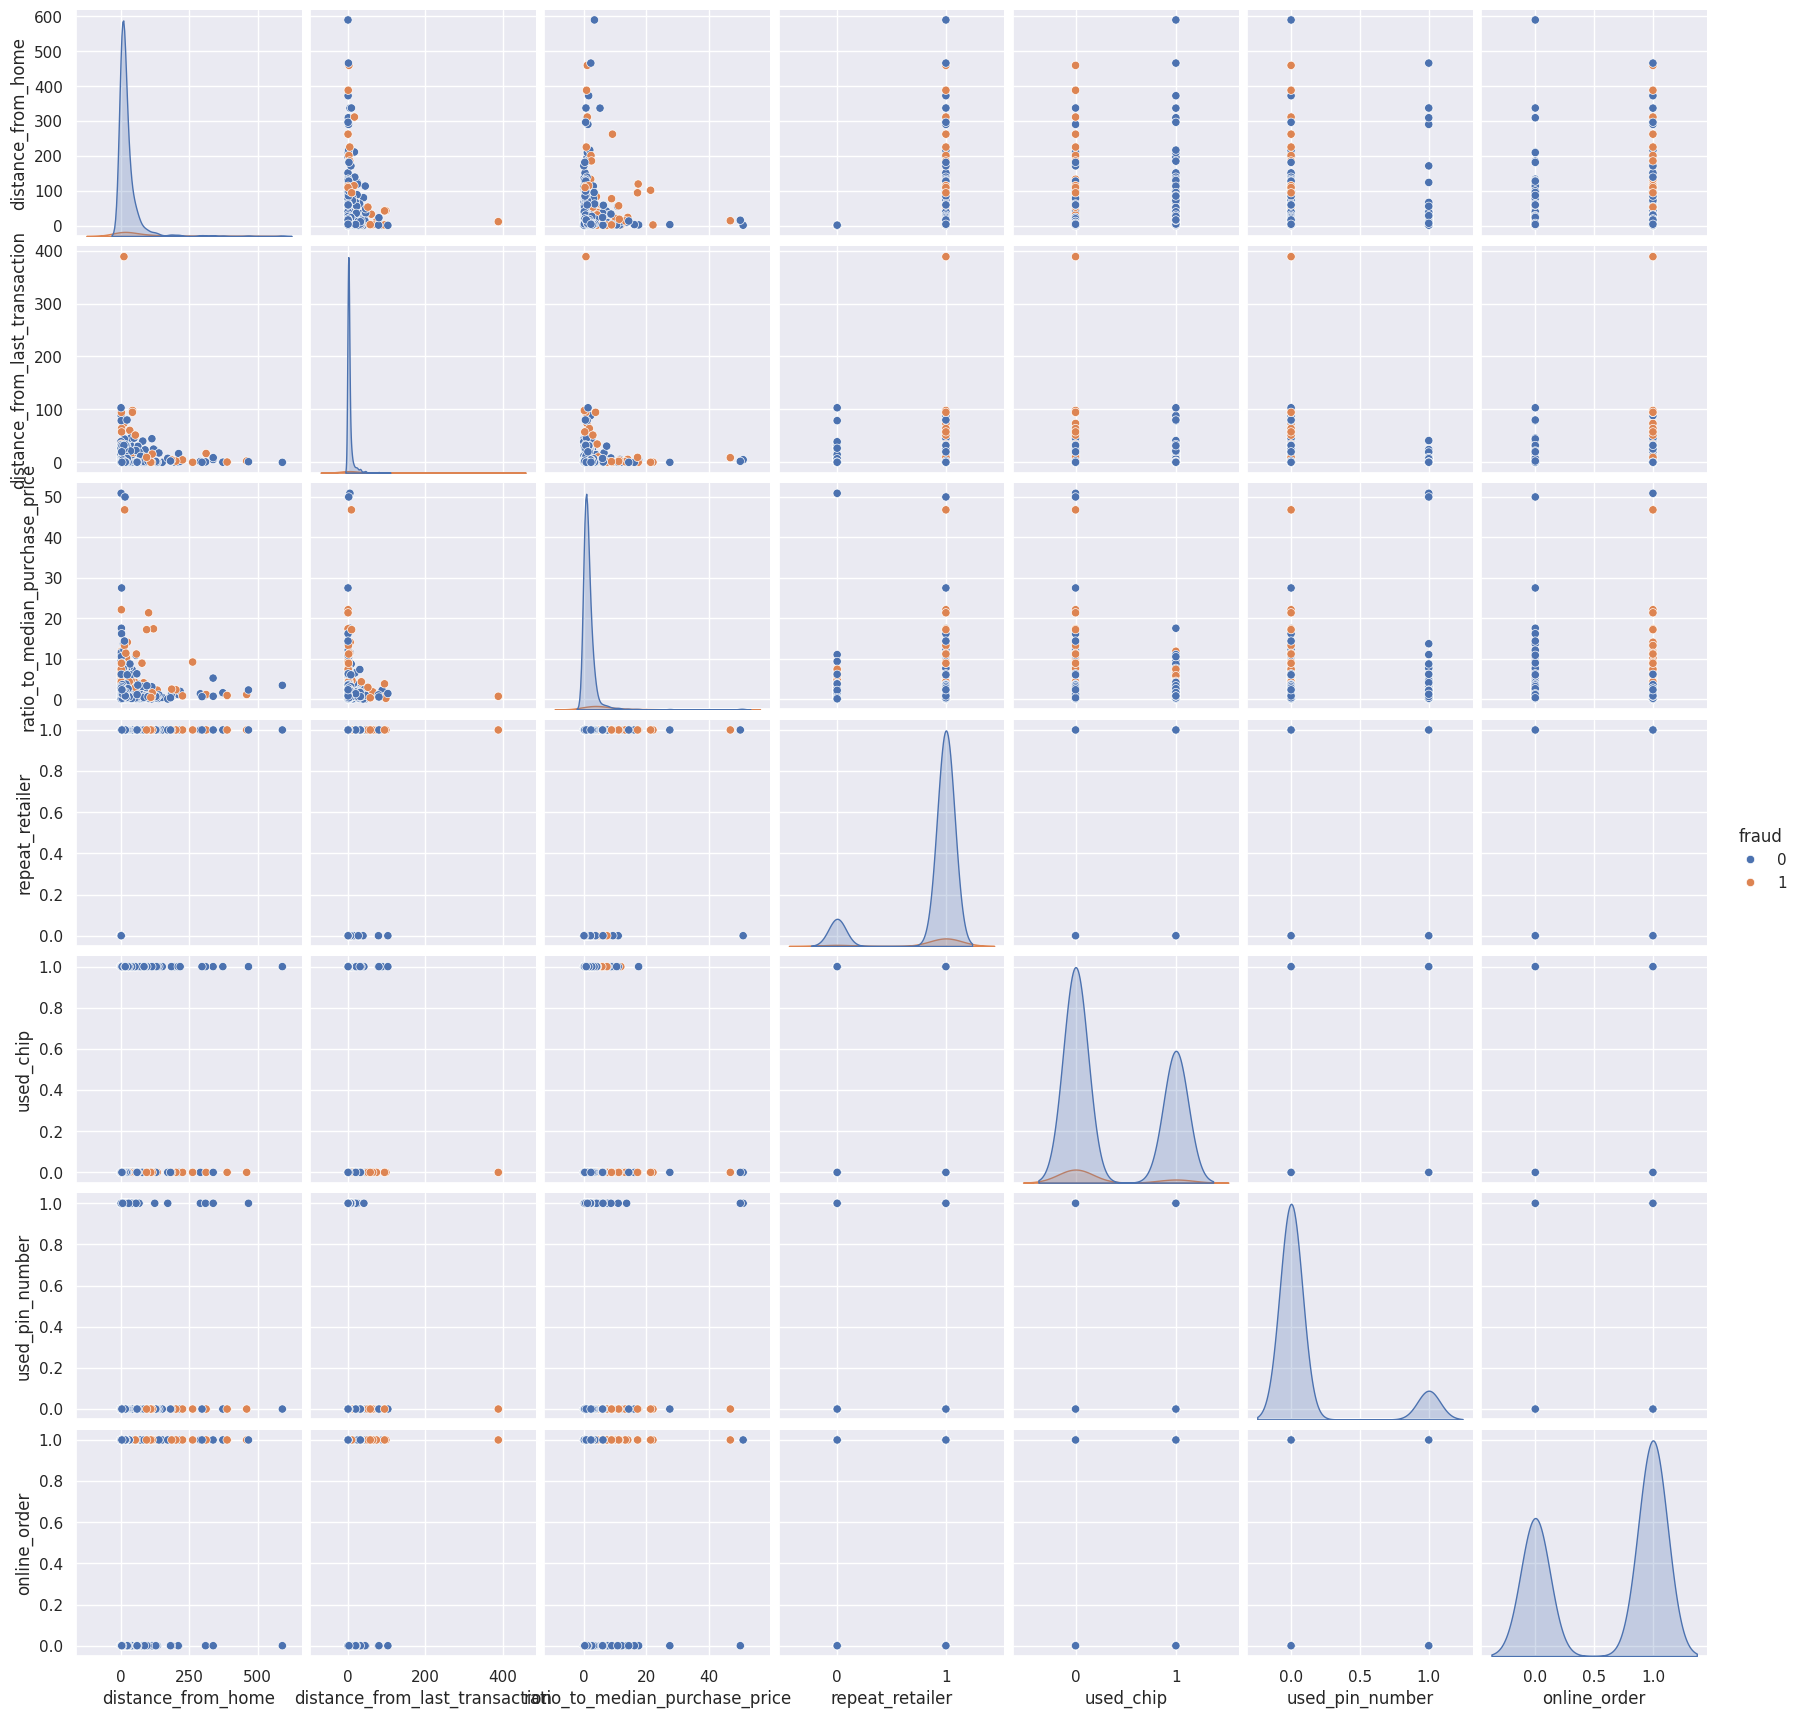

In [ ]:
sns.pairplot(data=df1.sample(1000), hue='fraud') # We use a sample of 1000 rows, to speed up the visualisation. A smaller sample is sufficient to reveal the general distribution.
plt.show()

**Observation**

#### **Feature Distributions (Diagonal Plots)**

* **`distance_from_home` and `distance_from_last_transaction`:**
    * The distribution for both features is heavily **skewed to the right** (many low values, a few very high values).
    * **Fraudulent transactions (`fraud` = 1, orange)** appear to have a slightly **wider and flatter distribution** (heavier tails) than non-fraudulent ones (`fraud` = 0, blue), meaning very high distances are more often associated with fraud.

* **`ratio_to_median_purchase_price`:**
    * This distribution is also **highly skewed to the right**.
    * The fraud distribution (orange) is **more spread out** and appears to have a higher mean/median than the non-fraudulent distribution (blue). This suggests transactions with a purchase price significantly higher than the median are more likely to be fraudulent.

* **Categorical/Binary Features (`repeat_retailer`, `used_chip`, `used_pin_number`, `online_order`):**
    * These are binary (0 or 1). The diagonal plots show the relative proportion of 0s and 1s.
    * **`used_chip` and `used_pin_number`:** The majority of transactions (both fraudulent and non-fraudulent) are clustered at 0 (did **not** use a chip/PIN).
    * **`online_order`:** There's a near 50/50 split between online (1) and non-online (0) orders.

#### **Pairwise Relationships (Off-Diagonal Plots)**

**Relationships with Fraud Separation**

The best features for separating fraud (orange) from non-fraud (blue) are:

* **`ratio_to_median_purchase_price` vs. other continuous features:** The scatter plots involving this feature show the most clear separation.
    * In the plot of **`ratio_to_median_purchase_price` vs. `distance_from_home`**, the **fraudulent points (orange) form a distinct cluster** in the upper-right area (high ratio, higher distance from home). This is a strong potential predictor.

* **`online_order`:** This feature shows a strong visual correlation with fraud when plotted against other features, especially when **`online_order` = 1**.
    * Looking at the bottom row (e.g., `online_order` vs. `distance_from_home`): Fraudulent transactions (orange) are disproportionately located in the `online_order` = 1 band.

#### **Relationships among Features**

* **`used_chip` and `used_pin_number`:**
    * The plot shows that transactions using a chip (`used_chip`=1) generally **do not** use a PIN (`used_pin_number`=0), and vice-versa, which is typical behavior for POS systems (either use the chip/signature or swipe/PIN).

* **No strong linear correlation:** None of the continuous features exhibit a clear, strong linear correlation with each other (the data points are not tightly clustered around a straight line).


## Data Preprocessing

Before we can train our deep learning model, we need to prepare the data properly.

Since all the features in our dataset are already in numerical format, we don't need to perform any encoding.

In this step, we will:
1. **Split the data** into training, validation, and test sets using a 70:15:15 ratio. This helps us train the model, tune it, and finally evaluate its performance on unseen data.
2. **Scale the features** using **MinMaxScaler** to bring all values into a similar range, which helps the model learn more effectively.

With this setup, we’re ready to move forward to model building.

#### **Train, Test, Validation Split**

**Why Split the Data into Train, Validation, and Test?**  
- **Train Set**: Used to fit the model and learn patterns.  
- **Validation Set**: Helps tune model parameters and prevent overfitting.  
- **Test Set**: Used only at the end to evaluate model performance on unseen data.  

This 3-way split ensures the model generalizes well and provides an unbiased estimate of its effectiveness.

In [ ]:
# Split data into training, validation, and test sets (70:15:15)
X = data.drop('fraud', axis=1)
y = data['fraud']

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

#### **Normalizing the numerical variables**

In [ ]:
# Normalize features using MinMaxScaler
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [ ]:
print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_val shape:", y_val.shape)
print("y_test shape:", y_test.shape)


X_train shape: (106918, 7)
X_val shape: (22911, 7)
X_test shape: (22911, 7)
y_train shape: (106918,)
y_val shape: (22911,)
y_test shape: (22911,)


## Model Building

With the data prepared, we now move to building and training Artificial Neural Networks (ANNs) to predict fraud. We'll experiment with different ANN architectures to find the most effective setup.

What We’ll Do:
1. **Define the ANN model** – Try out various architectures.
2. **Train the model** – Use training data to learn patterns.
3. **Validate and test** – Evaluate the model on unseen data.



### Model Evaluation Criterion

In fraud detection, the model can make wrong predictions as:  
- Predicting a transaction is fraudulent when it's not (False Positive)  
- Predicting a transaction is not fraudulent when it actually is (False Negative)

**Which case is more important?**  
Predicting that a transaction is not fraudulent when it actually is: i.e., **missing a fraud case** is more critical, as it can lead to financial losses and security risks.

**How to reduce this loss?**  
To minimize missed fraud cases (False Negatives), the company needs to **maximize Recall**. A higher Recall increases the chances of correctly identifying fraudulent transactions (True Positives). Therefore, the focus should be on increasing Recall to ensure that most fraud cases are caught, even if it leads to a few false alarms, thereby protecting the company from potential financial risks.

### Utility functions

In [ ]:
def plot(history, name):
    """
    Function to plot loss/accuracy

    history: an object which stores the metrics and losses.
    name: can be one of Loss or Accuracy
    """
    fig, ax = plt.subplots() #Creating a subplot with figure and axes.
    plt.plot(history.history[name]) #Plotting the train accuracy or train loss
    plt.plot(history.history['val_'+name]) #Plotting the validation accuracy or validation loss

    plt.title('Model ' + name.capitalize()) #Defining the title of the plot.
    plt.ylabel(name.capitalize()) #Capitalizing the first letter.
    plt.xlabel('Epoch') #Defining the label for the x-axis.
    fig.legend(['Train', 'Validation'], loc="outside right upper") #Defining the legend, loc controls the position of the legend.

We'll create a dataframe to store the results from all the models we build

In [ ]:
# Create a blank DataFrame to store the training and validation evaluation results of different models.

evaluation_results = pd.DataFrame(columns=['Model', '# hidden layers', '# neurons hidden layer', 'activation function hidden layer', 'configuration', '# epochs', 'batch size', 'Train_Loss', 'Train_Accuracy', 'Train_Precision', 'Train_Recall', 'Train_F1',
                                         'Val_Loss', 'Val_Accuracy', 'Val_Precision', 'Val_Recall', 'Val_F1'])


In [ ]:
evaluation_results

,Model,# hidden layers,# neurons hidden layer,activation function hidden layer,configuration,# epochs,batch size,Train_Loss,Train_Accuracy,Train_Precision,Train_Recall,Train_F1,Val_Loss,Val_Accuracy,Val_Precision,Val_Recall,Val_F1


### Model 0

We build this baseline neural network model using a simple architecture:

- **Input Layer:** The input shape is determined by the number of features in the training data, `X_train​`.
- **Hidden Layers:** We use two hidden layers, with 14 and 7 neurons each, both with **ReLU** activation function.
- **Output Layer:** One Dense layer with 1 unit and a sigmoid activation to handle binary classification.

**Loss Function:** We use Binary Crossentropy as the loss function, which is standard for binary classification problems.

**Optimizer:** We use Stochastic Gradient Descent (SGD) as the optimizer to adjust the network's weights during training.

**Metrics:** The model is evaluated using the Recall metric.

The model is trained for 50 epochs, with a batch size of 64.

In [ ]:
# clears the current Keras session, resetting all layers and models previously created, freeing up memory and resources.
tf.keras.backend.clear_session()

In [ ]:
#Initializing the neural network
model0 = Sequential()

model0.add(Dense(14, activation='relu', input_shape=(X_train.shape[1],))) # Hidden Layer 1
model0.add(Dense(7, activation='relu'))                       # Hidden Layer 2
model0.add(Dense(1, activation='sigmoid'))                    # Output Layer

In [ ]:
#Printing the summary
model0.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 14)             │           112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           105 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             8 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225 (900.00 B)

 Trainable params: 225 (900.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
optimizer = 'sgd'   # defining SGD as the optimizer to be used
loss = 'binary_crossentropy'   # defining binary crossentropy as the loss function

#Compiling the model.
model0.compile(loss=loss, optimizer=optimizer, metrics=[tf.keras.metrics.Recall(), tf.keras.metrics.Precision(), tf.keras.metrics.BinaryAccuracy()])

In [ ]:
epochs = 50   # training the model for 25 epochs
batch_size = 64    # setting the batch size equal to the number of rows

# time.time() returns the time in seconds since Thu Jan 1 00:00:00 1970.
start = time.time()

# Fitting the model.
history0 = model0.fit(X_train, y_train,
                      validation_data=(X_val,y_val) ,
                      batch_size=batch_size,
                      epochs=epochs)

# time.time() returns the time in seconds since Thu Jan 1 00:00:00 1970.
end = time.time()

Epoch 1/50
1671/1671 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - binary_accuracy: 0.8871 - loss: 0.4172 - precision: 0.0415 - recall: 0.0487 - val_binary_accuracy: 0.9428 - val_loss: 0.2296 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/50
1671/1671 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - binary_accuracy: 0.9433 - loss: 0.2244 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_binary_accuracy: 0.9428 - val_loss: 0.2205 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 3/50
1671/1671 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - binary_accuracy: 0.9433 - loss: 0.2186 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_binary_accuracy: 0.9428 - val_loss: 0.2195 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 4/50
1671/1671 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - binary_accuracy: 0.9433 - loss: 0.2179 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_binary_accuracy: 0.9428 - val_loss: 0.2193 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 5/50
1671/1671 ━━━━━━━━━━━━━━━━━━━

In [ ]:
print("Time taken in seconds ",end-start)

Time taken in seconds  270.71587324142456


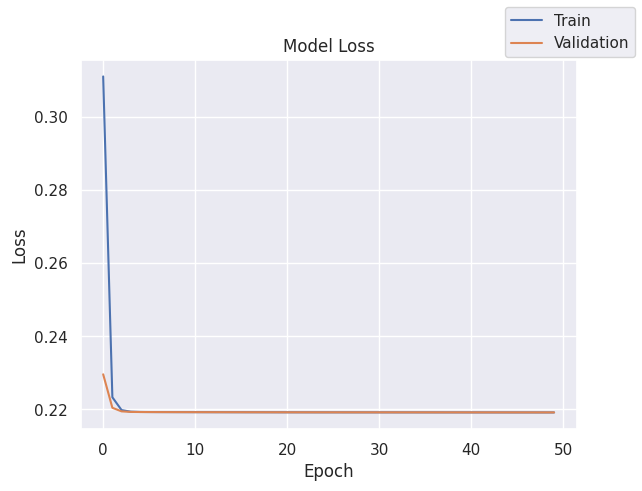

In [ ]:
plot(history0,'loss')

In [ ]:
evaluation_results.loc[0] = ['Model 0', '2', '[14, 7]', 'ReLU', 'baseline', epochs, batch_size, history0.history["loss"][-1], history0.history["binary_accuracy"][-1], history0.history["precision"][-1], history0.history["recall"][-1], 2 * (history0.history["precision"][-1] * history0.history["recall"][-1]) / (history0.history["precision"][-1] + history0.history["recall"][-1] + 1e-7), history0.history["val_loss"][-1], history0.history["val_binary_accuracy"][-1], history0.history["val_precision"][-1], history0.history["val_recall"][-1], 2 * (history0.history["val_precision"][-1] * history0.history["val_recall"][-1]) / (history0.history["val_precision"][-1] + history0.history["val_recall"][-1] + 1e-7)]
evaluation_results

,Model,# hidden layers,# neurons hidden layer,activation function hidden layer,configuration,# epochs,batch size,Train_Loss,Train_Accuracy,Train_Precision,Train_Recall,Train_F1,Val_Loss,Val_Accuracy,Val_Precision,Val_Recall,Val_F1
0,Model 0,2,"[14, 7]",ReLU,baseline,50,64,0.21919,0.942779,0.0,0.0,0.0,0.219198,0.942779,0.0,0.0,0.0


- The model shows very high accuracy but essentially zero precision, recall, and F1 score. This strongly suggests it is predicting almost only the majority class and largely ignoring the minority class, making it practically useless for meaningful classification.

- The training and validation loss curves move together very closely with no visible divergence. This indicates the model is not overfitting: it isn’t memorizing the training data, but it also isn’t capturing the subtle patterns needed to correctly classify the minority class.

- Both training and validation losses settle at similar, relatively low values, suggesting the model generalizes to the validation set but remains shallow in what it has learned.

- The loss drops quickly in the first few epochs, then becomes almost completely flat, which suggests the optimizer may have reached a local minimum and stopped making meaningful progress.

- A reasonable next step is to introduce momentum to the optimizer to help the
model escape this apparent local minimum and explore more promising regions of the loss surface.

### Model 1

We built our second neural network model with the following changes:

- The same architecture as the first model.
- We use a **momentum of 0.9** for the optimizer
- The model is trained for 50 epochs using a mini-batch gradient descent approach with a batch size of 64.

**Loss Function:** We use Binary Crossentropy as the loss function, which is standard for binary classification problems.

**Optimizer:** We use Stochastic Gradient Descent (SGD) as the optimizer to adjust the network's weights during training.

**Metrics:** The model is evaluated using the Recall metric.


In [ ]:
# clears the current Keras session, resetting all layers and models previously created, freeing up memory and resources.
tf.keras.backend.clear_session()

In [ ]:
#Initializing the neural network
model1 = Sequential()

model1.add(Dense(14, activation='relu', input_shape=(X_train.shape[1],)))
model1.add(Dense(7, activation='relu'))
model1.add(Dense(1, activation='sigmoid'))

In [ ]:
model1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 14)             │           112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           105 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             8 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225 (900.00 B)

 Trainable params: 225 (900.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
optimizer = tf.keras.optimizers.SGD(momentum=0.9)   # Adding momentum to accelerate learning
loss = 'binary_crossentropy'  # defining binary crossentropy as the loss function

model1.compile(loss=loss, optimizer=optimizer, metrics=[tf.keras.metrics.Recall(), tf.keras.metrics.Precision(), tf.keras.metrics.BinaryAccuracy()])

In [ ]:
epochs = 50
batch_size = 64

start = time.time()
history1 = model1.fit(X_train, y_train, validation_data=(X_val,y_val) , batch_size=batch_size, epochs=epochs)
end = time.time()

Epoch 1/50
1671/1671 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - binary_accuracy: 0.9257 - loss: 0.2381 - precision: 0.0597 - recall: 0.0211 - val_binary_accuracy: 0.9428 - val_loss: 0.1915 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/50
1671/1671 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - binary_accuracy: 0.9433 - loss: 0.1885 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_binary_accuracy: 0.9428 - val_loss: 0.1797 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 3/50
1671/1671 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - binary_accuracy: 0.9433 - loss: 0.1731 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_binary_accuracy: 0.9428 - val_loss: 0.1513 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 4/50
1671/1671 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - binary_accuracy: 0.9490 - loss: 0.1347 - precision: 0.6982 - recall: 0.1018 - val_binary_accuracy: 0.9623 - val_loss: 0.1049 - val_precision: 0.9461 - val_recall: 0.3616
Epoch 5/50
1671/1671 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - 

In [ ]:
print("Time taken in seconds ",end-start)

Time taken in seconds  323.4644477367401


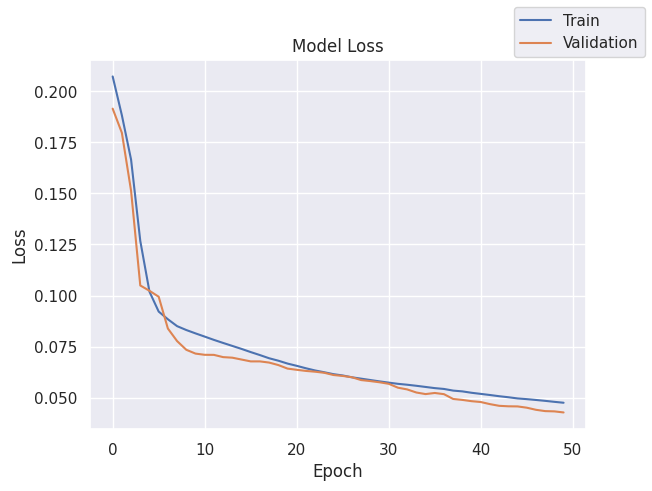

In [ ]:
plot(history1,'loss')

In [ ]:
evaluation_results.loc[1] = ['Model 1', '2', '[14, 7]', 'ReLU', 'momentum=0.9', epochs, batch_size, history1.history["loss"][-1], history1.history["binary_accuracy"][-1], history1.history["precision"][-1], history1.history["recall"][-1], 2 * (history1.history["precision"][-1] * history1.history["recall"][-1]) / (history1.history["precision"][-1] + history1.history["recall"][-1] + 1e-7), history1.history["val_loss"][-1], history1.history["val_binary_accuracy"][-1], history1.history["val_precision"][-1], history1.history["val_recall"][-1], 2 * (history1.history["val_precision"][-1] * history1.history["val_recall"][-1]) / (history1.history["val_precision"][-1] + history1.history["val_recall"][-1] + 1e-7)]
evaluation_results

,Model,# hidden layers,# neurons hidden layer,activation function hidden layer,configuration,# epochs,batch size,Train_Loss,Train_Accuracy,Train_Precision,Train_Recall,Train_F1,Val_Loss,Val_Accuracy,Val_Precision,Val_Recall,Val_F1
0,Model 0,2,"[14, 7]",ReLU,baseline,50,64,0.219190,0.942779,0.000000,0.000000,0.000000,0.219198,0.942779,0.00000,0.000000,0.000000
1,Model 1,2,"[14, 7]",ReLU,momentum=0.9,50,64,0.047537,0.983174,0.909229,0.784243,0.842124,0.042791,0.983894,0.97006,0.741419,0.840467


- Adding momentum helped the model escape the previous local minimum where it was effectively predicting only the majority class. It is now learning meaningful features instead of defaulting to a single class.
- Validation recall has improved dramatically, so the model is now correctly identifying a substantial portion of the minority (positive) cases.
- The loss has decreased significantly compared to the earlier model, showing that the new model fits the data much better.
- There is a small generalization gap: recall on the training data is higher than on the validation data, indicating some degree of overfitting but still acceptable performance on unseen data.
- Next, we can experiment with the Adam optimizer to observe how it impacts learning dynamics and model performance.

### Model 2

We built our third neural network model with the following changes:

- The same architecture as the baseline model. Use of Adam as the optimizer to automatically adjust the learning rate for each weight.

**Loss Function:** We use Binary Crossentropy as the loss function, which is standard for binary classification problems.

**Optimizer:** We use Adam as the optimizer for this model.

**Metrics:** The model is evaluated using the Recall metric.

In [ ]:
# clears the current Keras session, resetting all layers and models previously created, freeing up memory and resources.
tf.keras.backend.clear_session()

In [ ]:
#Initializing the neural network
model2 = Sequential()
model2.add(Dense(14, activation='relu', input_shape=(X_train.shape[1],)))
model2.add(Dense(7, activation='relu'))
model2.add(Dense(1, activation='sigmoid'))

In [ ]:
model2.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 14)             │           112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           105 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             8 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225 (900.00 B)

 Trainable params: 225 (900.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
optimizer = 'adam'   # defining SGD as the optimizer to be used
loss = 'binary_crossentropy'
model2.compile(loss=loss, optimizer=optimizer, metrics=[tf.keras.metrics.Recall(), tf.keras.metrics.Precision(), tf.keras.metrics.BinaryAccuracy()])

In [ ]:
epochs = 50
batch_size = 64

start = time.time()
history2 = model2.fit(X_train, y_train, validation_data=(X_val,y_val) , batch_size=batch_size, epochs=epochs)
end = time.time()

Epoch 1/50
1671/1671 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - binary_accuracy: 0.9162 - loss: 0.2759 - precision: 0.0472 - recall: 0.0248 - val_binary_accuracy: 0.9485 - val_loss: 0.1366 - val_precision: 0.9119 - val_recall: 0.1106
Epoch 2/50
1671/1671 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - binary_accuracy: 0.9565 - loss: 0.1164 - precision: 0.9080 - recall: 0.2582 - val_binary_accuracy: 0.9700 - val_loss: 0.0819 - val_precision: 0.8768 - val_recall: 0.5538
Epoch 3/50
1671/1671 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - binary_accuracy: 0.9721 - loss: 0.0783 - precision: 0.8701 - recall: 0.5970 - val_binary_accuracy: 0.9744 - val_loss: 0.0703 - val_precision: 0.8703 - val_recall: 0.6499
Epoch 4/50
1671/1671 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - binary_accuracy: 0.9750 - loss: 0.0688 - precision: 0.8567 - recall: 0.6714 - val_binary_accuracy: 0.9759 - val_loss: 0.0631 - val_precision: 0.8717 - val_recall: 0.6789
Epoch 5/50
1671/1671 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - binary_accuracy: 0.9769 - loss: 0.0620 -

In [ ]:
print("Time taken in seconds ",end-start)

Time taken in seconds  311.17043352127075


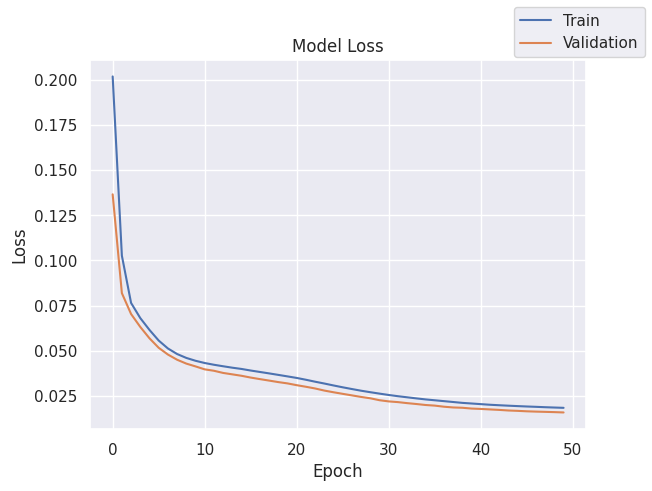

In [ ]:
plot(history2,'loss')

In [ ]:
evaluation_results.loc[2] = ['Model 2', '2', '[14, 7]', 'ReLU', 'optimizer=adam', epochs, batch_size, history2.history["loss"][-1], history2.history["binary_accuracy"][-1], history2.history["precision"][-1], history2.history["recall"][-1], 2 * (history2.history["precision"][-1] * history2.history["recall"][-1]) / (history2.history["precision"][-1] + history2.history["recall"][-1] + 1e-7), history2.history["val_loss"][-1], history2.history["val_binary_accuracy"][-1], history2.history["val_precision"][-1], history2.history["val_recall"][-1], 2 * (history2.history["val_precision"][-1] * history2.history["val_recall"][-1]) / (history2.history["val_precision"][-1] + history2.history["val_recall"][-1] + 1e-7)]
evaluation_results

,Model,# hidden layers,# neurons hidden layer,activation function hidden layer,configuration,# epochs,batch size,Train_Loss,Train_Accuracy,Train_Precision,Train_Recall,Train_F1,Val_Loss,Val_Accuracy,Val_Precision,Val_Recall,Val_F1
0,Model 0,2,"[14, 7]",ReLU,baseline,50,64,0.219190,0.942779,0.000000,0.000000,0.000000,0.219198,0.942779,0.000000,0.000000,0.000000
1,Model 1,2,"[14, 7]",ReLU,momentum=0.9,50,64,0.047537,0.983174,0.909229,0.784243,0.842124,0.042791,0.983894,0.970060,0.741419,0.840467
2,Model 2,2,"[14, 7]",ReLU,optimizer=adam,50,64,0.018321,0.992957,0.957686,0.917457,0.937140,0.015764,0.994326,0.972022,0.927536,0.949258


- Switching the optimizer from SGD to Adam produced the strongest results so far. This new model outperforms the previous versions on all key evaluation metrics.
- Validation accuracy is extremely high, and the loss has dropped to a very low level, noticeably better than what was achieved by the earlier model with momentum.
-The earlier model with momentum had difficulty maintaining strong recall on unseen data. With Adam, recall on the validation set has increased substantially, indicating that the model now captures most of the positive (minority) cases.
- The gap between training recall and validation recall is now very small, which shows that the model generalizes well and is not significantly overfitting.
- Overall, this is one of the most balanced models so far: it achieves high detection rates while keeping false positives low, leading to strong precision.
- The learning process is smoother than before: the validation loss curve is stable and not jagged, unlike the model trained with SGD and momentum.
- The model reaches a low loss quickly and then continues to improve gradually without signs of overfitting.
- Next, we will increase the model’s complexity and introduce dropout to explore whether performance can be improved further while still controlling overfitting.

### Model 3

We built our **fourth neural network model** with the following changes:

- First hidden layer now has 28 neurons, up from 14.
- Second hidden layer now has 14 neurons, up from 7.
- Addition of Dropout layer (0.2) after each hidden layer, to prevent overfitting

**Loss Function:** We use Binary Crossentropy as the loss function, which is standard for binary classification problems.

**Optimizer:** We use Adam as the optimizer for this model.

**Metrics:** The model is evaluated using the Recall metric.



In [ ]:
# clears the current Keras session, resetting all layers and models previously created, freeing up memory and resources.
tf.keras.backend.clear_session()

In [ ]:
#Initializing the neural network
model3 = Sequential()
model3.add(Dense(28, activation='relu', input_shape=(X_train.shape[1],)))
model3.add(Dropout(0.3)) # Dropout layer to prevent overfitting
model3.add(Dense(14, activation='relu'))
model3.add(Dropout(0.3))
model3.add(Dense(1, activation='sigmoid'))

In [ ]:
model3.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 28)             │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 28)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 14)             │           406 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 14)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            15 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 645 (2.52 KB)

 Trainable params: 645 (2.52 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
optimizer = 'adam'   # defining SGD as the optimizer to be used
loss = 'binary_crossentropy'
model3.compile(loss=loss, optimizer=optimizer, metrics=[tf.keras.metrics.Recall(), tf.keras.metrics.Precision(), tf.keras.metrics.BinaryAccuracy()])

In [ ]:
epochs = 50
batch_size = 64

In [ ]:
start = time.time()
history3 = model3.fit(X_train, y_train, validation_data=(X_val,y_val) , batch_size=batch_size, epochs=epochs)
end = time.time()

Epoch 1/50
1671/1671 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - binary_accuracy: 0.9352 - loss: 0.2694 - precision: 0.0503 - recall: 0.0070 - val_binary_accuracy: 0.9477 - val_loss: 0.1245 - val_precision: 0.9590 - val_recall: 0.0892
Epoch 2/50
1671/1671 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - binary_accuracy: 0.9601 - loss: 0.1190 - precision: 0.8987 - recall: 0.3353 - val_binary_accuracy: 0.9753 - val_loss: 0.0723 - val_precision: 0.9326 - val_recall: 0.6117
Epoch 3/50
1671/1671 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - binary_accuracy: 0.9738 - loss: 0.0813 - precision: 0.8487 - recall: 0.6531 - val_binary_accuracy: 0.9807 - val_loss: 0.0578 - val_precision: 0.9358 - val_recall: 0.7117
Epoch 4/50
1671/1671 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - binary_accuracy: 0.9783 - loss: 0.0671 - precision: 0.8569 - recall: 0.7395 - val_binary_accuracy: 0.9825 - val_loss: 0.0520 - val_precision: 0.9374 - val_recall: 0.7429
Epoch 5/50
1671/1671 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - binary_accuracy: 0.9794 - loss: 0.0619 -

In [ ]:
print("Time taken in seconds ",end-start)

Time taken in seconds  328.3258535861969


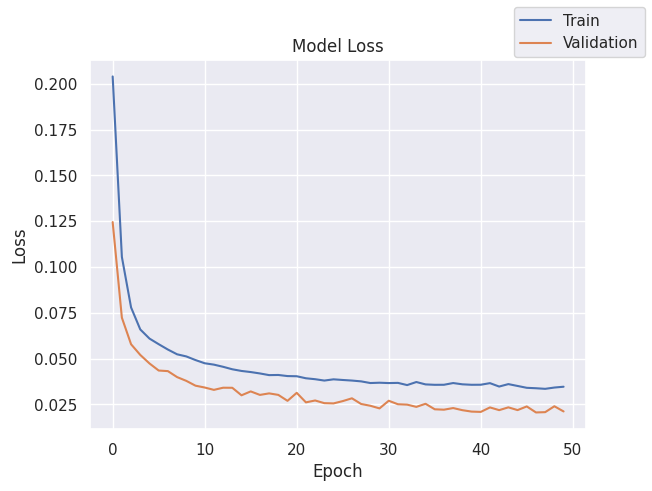

In [ ]:
plot(history3,'loss')

In [ ]:
evaluation_results.loc[3] = ['Model 3', '2', '[28, 14]', 'ReLU', 'Dropout(0.3)', epochs, batch_size, history3.history["loss"][-1], history3.history["binary_accuracy"][-1], history3.history["precision"][-1], history3.history["recall"][-1], 2 * (history3.history["precision"][-1] * history3.history["recall"][-1]) / (history3.history["precision"][-1] + history3.history["recall"][-1] + 1e-7), history3.history["val_loss"][-1], history3.history["val_binary_accuracy"][-1], history3.history["val_precision"][-1], history3.history["val_recall"][-1], 2 * (history3.history["val_precision"][-1] * history3.history["val_recall"][-1]) / (history3.history["val_precision"][-1] + history3.history["val_recall"][-1] + 1e-7)]
evaluation_results

,Model,# hidden layers,# neurons hidden layer,activation function hidden layer,configuration,# epochs,batch size,Train_Loss,Train_Accuracy,Train_Precision,Train_Recall,Train_F1,Val_Loss,Val_Accuracy,Val_Precision,Val_Recall,Val_F1
0,Model 0,2,"[14, 7]",ReLU,baseline,50,64,0.219190,0.942779,0.000000,0.000000,0.000000,0.219198,0.942779,0.000000,0.000000,0.000000
1,Model 1,2,"[14, 7]",ReLU,momentum=0.9,50,64,0.047537,0.983174,0.909229,0.784243,0.842124,0.042791,0.983894,0.970060,0.741419,0.840467
2,Model 2,2,"[14, 7]",ReLU,optimizer=adam,50,64,0.018321,0.992957,0.957686,0.917457,0.937140,0.015764,0.994326,0.972022,0.927536,0.949258
3,Model 3,2,"[28, 14]",ReLU,Dropout(0.3),50,64,0.034674,0.987430,0.921434,0.853057,0.885928,0.021193,0.991838,0.962932,0.891686,0.925941


- The most noticeable pattern in Model 3 is that the validation loss curve stays consistently below the training loss curve. This “inverted” behavior is typical when using dropout: during training, a portion of neurons is randomly disabled, making learning harder; during validation, all neurons are active, so the model performs relatively better.
- Even though the model architecture was made more complex and dropout was added as a regularization measure, Model 3 performs slightly worse than Model 2 on all key metrics.
- This suggests over-regularization: Model 2 was already fitting the data very well without signs of overfitting (training and validation losses were closely aligned). Adding dropout made the optimization problem harder without clear benefit, preventing the model from reaching the same level of convergence as Model 2.
- Next, we will introduce batch normalization to observe how it affects training stability and overall performance.

### Model 4

We built our **fifth neural network model** with the following changes:

- It uses Batch Normalization after each of the first two dense layers to help stabilize learning.

**Loss Function:** We use Binary Crossentropy as the loss function, which is standard for binary classification problems.

**Optimizer:** We use Adam as the optimizer for this model.

**Metrics:** The model is evaluated using the Recall metric.



In [ ]:
# clears the current Keras session, resetting all layers and models previously created, freeing up memory and resources.
tf.keras.backend.clear_session()

In [ ]:
#Initializing the neural network
model4 = Sequential()
model4.add(Dense(28, activation='relu', input_shape=(X_train.shape[1],)))
model4.add(BatchNormalization()) # Stabilizes learning
model4.add(Dense(14, activation='relu'))
model4.add(BatchNormalization())
model4.add(Dense(1, activation='sigmoid'))

In [ ]:
model4.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 28)             │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28)             │           112 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 14)             │           406 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14)             │            56 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            15 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 813 (3.18 KB)

 Trainable params: 729 (2.85 KB)

 Non-trainable params: 84 (336.00 B)

In [ ]:
optimizer = 'adam'   # defining SGD as the optimizer to be used
loss = 'binary_crossentropy'
model4.compile(loss=loss, optimizer=optimizer, metrics=[tf.keras.metrics.Recall(), tf.keras.metrics.Precision(), tf.keras.metrics.BinaryAccuracy()])

In [ ]:
epochs = 50
batch_size = 64

In [ ]:
start = time.time()
history4 = model4.fit(X_train, y_train, validation_data=(X_val,y_val) , batch_size=batch_size, epochs=epochs)
end = time.time()

Epoch 1/50
1671/1671 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - binary_accuracy: 0.9095 - loss: 0.2750 - precision: 0.4506 - recall: 0.5330 - val_binary_accuracy: 0.9791 - val_loss: 0.0689 - val_precision: 0.8428 - val_recall: 0.7811
Epoch 2/50
1671/1671 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - binary_accuracy: 0.9800 - loss: 0.0547 - precision: 0.8867 - recall: 0.7404 - val_binary_accuracy: 0.9734 - val_loss: 0.0742 - val_precision: 0.7070 - val_recall: 0.9146
Epoch 3/50
1671/1671 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - binary_accuracy: 0.9840 - loss: 0.0438 - precision: 0.9105 - recall: 0.7951 - val_binary_accuracy: 0.9904 - val_loss: 0.0364 - val_precision: 0.9167 - val_recall: 0.9146
Epoch 4/50
1671/1671 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - binary_accuracy: 0.9866 - loss: 0.0382 - precision: 0.9233 - recall: 0.8332 - val_binary_accuracy: 0.9917 - val_loss: 0.0280 - val_precision: 0.9452 - val_recall: 0.9069
Epoch 5/50
1671/1671 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - binary_accuracy: 0.9878 - loss: 0.0341 

In [ ]:
print("Time taken in seconds ",end-start)

Time taken in seconds  391.3189685344696


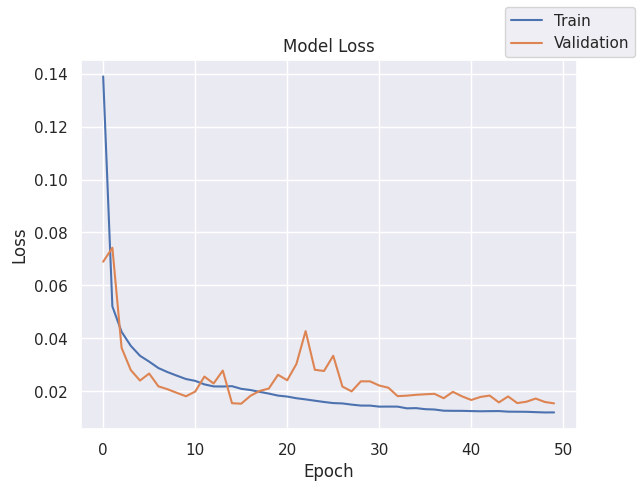

In [ ]:
plot(history4,'loss')

In [ ]:
evaluation_results.loc[4] = ['Model 4', '2', '[28, 14]', 'ReLU', 'BatchNormalization()', epochs, batch_size, history4.history["loss"][-1], history4.history["binary_accuracy"][-1], history4.history["precision"][-1], history4.history["recall"][-1], 2 * (history4.history["precision"][-1] * history4.history["recall"][-1]) / (history4.history["precision"][-1] + history4.history["recall"][-1] + 1e-7), history4.history["val_loss"][-1], history4.history["val_binary_accuracy"][-1], history4.history["val_precision"][-1], history4.history["val_recall"][-1], 2 * (history4.history["val_precision"][-1] * history4.history["val_recall"][-1]) / (history4.history["val_precision"][-1] + history4.history["val_recall"][-1] + 1e-7)]
evaluation_results

,Model,# hidden layers,# neurons hidden layer,activation function hidden layer,configuration,# epochs,batch size,Train_Loss,Train_Accuracy,Train_Precision,Train_Recall,Train_F1,Val_Loss,Val_Accuracy,Val_Precision,Val_Recall,Val_F1
0,Model 0,2,"[14, 7]",ReLU,baseline,50,64,0.219190,0.942779,0.000000,0.000000,0.000000,0.219198,0.942779,0.000000,0.000000,0.000000
1,Model 1,2,"[14, 7]",ReLU,momentum=0.9,50,64,0.047537,0.983174,0.909229,0.784243,0.842124,0.042791,0.983894,0.970060,0.741419,0.840467
2,Model 2,2,"[14, 7]",ReLU,optimizer=adam,50,64,0.018321,0.992957,0.957686,0.917457,0.937140,0.015764,0.994326,0.972022,0.927536,0.949258
3,Model 3,2,"[28, 14]",ReLU,Dropout(0.3),50,64,0.034674,0.987430,0.921434,0.853057,0.885928,0.021193,0.991838,0.962932,0.891686,0.925941
4,Model 4,2,"[28, 14]",ReLU,BatchNormalization(),50,64,0.011986,0.995043,0.965047,0.947695,0.956292,0.015395,0.997338,0.982998,0.970252,0.976583


- Model 4 is essentially the strongest model so far. Adding batch normalization has produced the best overall balance across all key evaluation metrics.
- The most important gain is in recall (sensitivity). Model 4 now detects almost all positive cases, while an earlier strong model was still missing a noticeable fraction of them-an especially important improvement for high‑risk applications like fraud detection.
- The loss curve shows that training loss drops very quickly right from the start. This rapid convergence is a well-known effect of batch normalization, which stabilizes the activations passed between layers and allows the model to learn more efficiently.
- Next, we will combine both dropout and batch normalization to see whether we can further improve performance while maintaining good regularization.

### Model 5

We built our **sixth neural network model** with the following changes:

- Addition of BOTH Dropout layer (0.2) and Batch Normalization after each dense layer.

**Loss Function:** We use Binary Crossentropy as the loss function, which is standard for binary classification problems.

**Optimizer:** We use Adam as the optimizer for this model.

**Metrics:** The model is evaluated using the Recall metric.



In [ ]:
# clears the current Keras session, resetting all layers and models previously created, freeing up memory and resources.
tf.keras.backend.clear_session()

In [ ]:
#Initializing the neural network
model5 = Sequential()
model5.add(Dense(28, activation='relu', input_shape=(X_train.shape[1],)))
model5.add(BatchNormalization())
model5.add(Dropout(0.2)) # Combining techniques
model5.add(Dense(14, activation='relu'))
model5.add(BatchNormalization())
model5.add(Dropout(0.2))
model5.add(Dense(1, activation='sigmoid'))

In [ ]:
model5.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 28)             │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28)             │           112 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 28)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 14)             │           406 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14)             │            56 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 14)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            15 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 813 (3.18 KB)

 Trainable params: 729 (2.85 KB)

 Non-trainable params: 84 (336.00 B)

In [ ]:
optimizer = 'adam'   # defining SGD as the optimizer to be used
loss = 'binary_crossentropy'
model5.compile(loss=loss, optimizer=optimizer,metrics=[tf.keras.metrics.Recall(), tf.keras.metrics.Precision(), tf.keras.metrics.BinaryAccuracy()])

In [ ]:
epochs = 50
batch_size = 64

In [ ]:
start = time.time()
history5 = model5.fit(X_train, y_train, validation_data=(X_val,y_val) , batch_size=batch_size, epochs=epochs)
end = time.time()

Epoch 1/50
1671/1671 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - binary_accuracy: 0.8482 - loss: 0.3456 - precision: 0.2269 - recall: 0.4180 - val_binary_accuracy: 0.9802 - val_loss: 0.0597 - val_precision: 0.9214 - val_recall: 0.7155
Epoch 2/50
1671/1671 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - binary_accuracy: 0.9732 - loss: 0.0769 - precision: 0.8341 - recall: 0.6581 - val_binary_accuracy: 0.9832 - val_loss: 0.0533 - val_precision: 0.8918 - val_recall: 0.8047
Epoch 3/50
1671/1671 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - binary_accuracy: 0.9769 - loss: 0.0651 - precision: 0.8477 - recall: 0.7206 - val_binary_accuracy: 0.9805 - val_loss: 0.0502 - val_precision: 0.9355 - val_recall: 0.7079
Epoch 4/50
1671/1671 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - binary_accuracy: 0.9782 - loss: 0.0599 - precision: 0.8486 - recall: 0.7493 - val_binary_accuracy: 0.9847 - val_loss: 0.0409 - val_precision: 0.9203 - val_recall: 0.8017
Epoch 5/50
1671/1671 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - binary_accuracy: 0.9792 - loss: 0.0561

In [ ]:
print("Time taken in seconds ",end-start)

Time taken in seconds  345.75880098342896


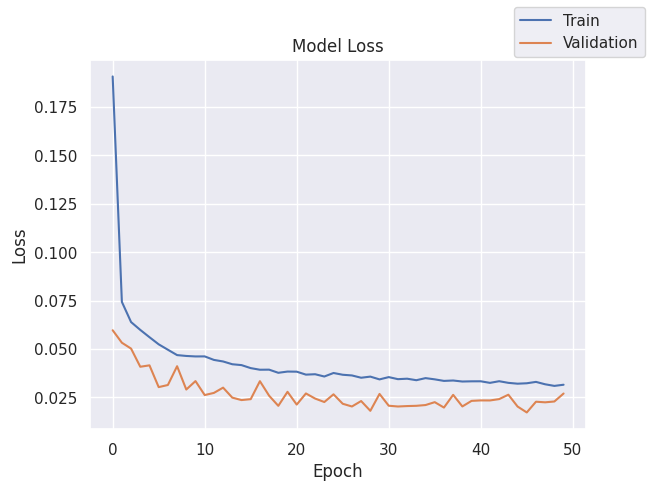

In [ ]:
plot(history5,'loss')

In [ ]:
evaluation_results.loc[5] = ['Model 5', '2', '[28, 14]', 'ReLU', 'Dropout(0.3) & BatchNormalization()', epochs, batch_size, history5.history["loss"][-1], history5.history["binary_accuracy"][-1], history5.history["precision"][-1], history5.history["recall"][-1], 2 * (history5.history["precision"][-1] * history5.history["recall"][-1]) / (history5.history["precision"][-1] + history5.history["recall"][-1] + 1e-7), history5.history["val_loss"][-1], history5.history["val_binary_accuracy"][-1], history5.history["val_precision"][-1], history5.history["val_recall"][-1], 2 * (history5.history["val_precision"][-1] * history5.history["val_recall"][-1]) / (history5.history["val_precision"][-1] + history5.history["val_recall"][-1] + 1e-7)]
evaluation_results

,Model,# hidden layers,# neurons hidden layer,activation function hidden layer,configuration,# epochs,batch size,Train_Loss,Train_Accuracy,Train_Precision,Train_Recall,Train_F1,Val_Loss,Val_Accuracy,Val_Precision,Val_Recall,Val_F1
0,Model 0,2,"[14, 7]",ReLU,baseline,50,64,0.219190,0.942779,0.000000,0.000000,0.000000,0.219198,0.942779,0.000000,0.000000,0.000000
1,Model 1,2,"[14, 7]",ReLU,momentum=0.9,50,64,0.047537,0.983174,0.909229,0.784243,0.842124,0.042791,0.983894,0.970060,0.741419,0.840467
2,Model 2,2,"[14, 7]",ReLU,optimizer=adam,50,64,0.018321,0.992957,0.957686,0.917457,0.937140,0.015764,0.994326,0.972022,0.927536,0.949258
3,Model 3,2,"[28, 14]",ReLU,Dropout(0.3),50,64,0.034674,0.987430,0.921434,0.853057,0.885928,0.021193,0.991838,0.962932,0.891686,0.925941
4,Model 4,2,"[28, 14]",ReLU,BatchNormalization(),50,64,0.011986,0.995043,0.965047,0.947695,0.956292,0.015395,0.997338,0.982998,0.970252,0.976583
5,Model 5,2,"[28, 14]",ReLU,Dropout(0.3) & BatchNormalization(),50,64,0.031569,0.988178,0.913177,0.876757,0.894596,0.027028,0.989132,0.975806,0.830664,0.897404


- Compared with the batch‑normalization‑only model (Model 4) , this model (with both batch normalization and dropout) shows a clear drop in performance on the main target metric, recall.
- As with the earlier dropout model (Model 3), the validation loss consistently stays below the training loss. This pattern indicates that dropout is strongly hindering performance during training, while validation (without dropout) appears easier.
- The training loss reaches a plateau at a noticeably higher value than in the batch‑normalization‑only model. The extra noise from dropout prevents the model from refining its parameters to the same level of precision, leading to weaker overall performance.



### Model 6

We built our **seventh neural network model** with the following changes:

- It explicitly uses the He normal (kernel_initializer='he_normal') for the weights of the hidden layers. This is the preferred initializer for ReLU activation and is intended to help the network learn more effectively.

- It includes a Dropout layer (0.3) after each of the first two dense layers to help prevent overfitting.

**Loss Function:** We use Binary Crossentropy as the loss function, which is standard for binary classification problems.

**Optimizer:** We use Adam as the optimizer for this model.

**Metrics:** The model is evaluated using the Recall metric.



In [ ]:
# clears the current Keras session, resetting all layers and models previously created, freeing up memory and resources.
tf.keras.backend.clear_session()

In [ ]:
#Initializing the neural network
model6 = Sequential()
# 'he_normal' is the preferred initializer for ReLU activation
model6.add(Dense(28, activation='relu', kernel_initializer='he_normal', input_shape=(X_train.shape[1],)))
model6.add(Dropout(0.3))
model6.add(Dense(14, activation='relu', kernel_initializer='he_normal'))
model6.add(Dropout(0.3))
model6.add(Dense(1, activation='sigmoid'))

In [ ]:
model6.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 28)             │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 28)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 14)             │           406 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 14)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            15 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 645 (2.52 KB)

 Trainable params: 645 (2.52 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
optimizer = 'adam'   # defining SGD as the optimizer to be used
loss = 'binary_crossentropy'
model6.compile(loss=loss, optimizer=optimizer, metrics=[tf.keras.metrics.Recall(), tf.keras.metrics.Precision(), tf.keras.metrics.BinaryAccuracy()])

In [ ]:
epochs = 50
batch_size = 64

In [ ]:
start = time.time()
history6 = model6.fit(X_train, y_train, validation_data=(X_val,y_val) , batch_size=batch_size, epochs=epochs)
end = time.time()

Epoch 1/50
1671/1671 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - binary_accuracy: 0.8500 - loss: 0.3780 - precision: 0.0615 - recall: 0.1143 - val_binary_accuracy: 0.9447 - val_loss: 0.1453 - val_precision: 0.9400 - val_recall: 0.0359
Epoch 2/50
1671/1671 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - binary_accuracy: 0.9516 - loss: 0.1455 - precision: 0.8875 - recall: 0.1648 - val_binary_accuracy: 0.9717 - val_loss: 0.0832 - val_precision: 0.9462 - val_recall: 0.5362
Epoch 3/50
1671/1671 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - binary_accuracy: 0.9684 - loss: 0.0995 - precision: 0.8753 - recall: 0.5150 - val_binary_accuracy: 0.9790 - val_loss: 0.0634 - val_precision: 0.9580 - val_recall: 0.6613
Epoch 4/50
1671/1671 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - binary_accuracy: 0.9752 - loss: 0.0777 - precision: 0.8740 - recall: 0.6561 - val_binary_accuracy: 0.9829 - val_loss: 0.0533 - val_precision: 0.9483 - val_recall: 0.7422
Epoch 5/50
1671/1671 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - binary_accuracy: 0.9794 - loss: 0.0672 

In [ ]:
print("Time taken in seconds ",end-start)

Time taken in seconds  345.75880098342896


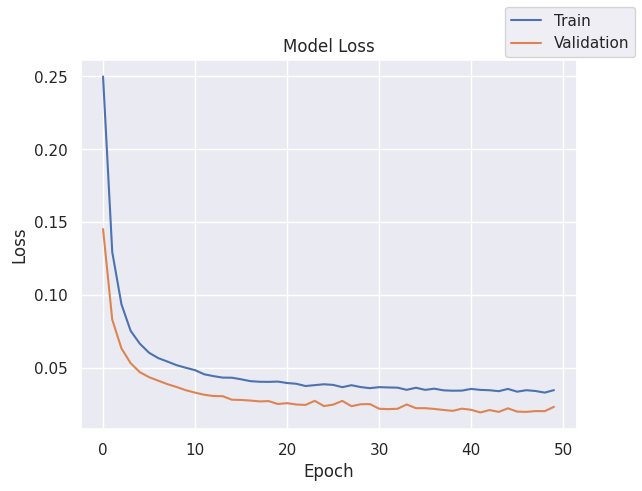

In [ ]:
plot(history6,'loss')

In [ ]:
evaluation_results.loc[6] = ['Model 6', '2', '[28, 14]', 'ReLU', "kernel_initializer=\'he_normal\'", epochs, batch_size, history6.history["loss"][-1], history6.history["binary_accuracy"][-1], history6.history["precision"][-1], history6.history["recall"][-1], 2 * (history6.history["precision"][-1] * history6.history["recall"][-1]) / (history6.history["precision"][-1] + history6.history["recall"][-1] + 1e-7), history6.history["val_loss"][-1], history6.history["val_binary_accuracy"][-1], history6.history["val_precision"][-1], history6.history["val_recall"][-1], 2 * (history6.history["val_precision"][-1] * history6.history["val_recall"][-1]) / (history6.history["val_precision"][-1] + history6.history["val_recall"][-1] + 1e-7)]
evaluation_results

,Model,# hidden layers,# neurons hidden layer,activation function hidden layer,configuration,# epochs,batch size,Train_Loss,Train_Accuracy,Train_Precision,Train_Recall,Train_F1,Val_Loss,Val_Accuracy,Val_Precision,Val_Recall,Val_F1
0,Model 0,2,"[14, 7]",ReLU,baseline,50,64,0.219190,0.942779,0.000000,0.000000,0.000000,0.219198,0.942779,0.000000,0.000000,0.000000
1,Model 1,2,"[14, 7]",ReLU,momentum=0.9,50,64,0.047537,0.983174,0.909229,0.784243,0.842124,0.042791,0.983894,0.970060,0.741419,0.840467
2,Model 2,2,"[14, 7]",ReLU,optimizer=adam,50,64,0.018321,0.992957,0.957686,0.917457,0.937140,0.015764,0.994326,0.972022,0.927536,0.949258
3,Model 3,2,"[28, 14]",ReLU,Dropout(0.3),50,64,0.034674,0.987430,0.921434,0.853057,0.885928,0.021193,0.991838,0.962932,0.891686,0.925941
4,Model 4,2,"[28, 14]",ReLU,BatchNormalization(),50,64,0.011986,0.995043,0.965047,0.947695,0.956292,0.015395,0.997338,0.982998,0.970252,0.976583
5,Model 5,2,"[28, 14]",ReLU,Dropout(0.3) & BatchNormalization(),50,64,0.031569,0.988178,0.913177,0.876757,0.894596,0.027028,0.989132,0.975806,0.830664,0.897404
6,Model 6,2,"[28, 14]",ReLU,kernel_initializer='he_normal',50,64,0.034801,0.987869,0.927166,0.855181,0.889720,0.023358,0.992711,0.988889,0.882532,0.932688


- The model achieves strong validation recall and F1 score, but it still does not surpass the best earlier models.
- He initialization is theoretically well suited for networks using ReLU activations. However, even with this “best-practice” initialization, this model did not outperform previous architectures.
- When compared with the earlier dropout model using the default initializer (Model 3), the validation recall is effectively the same (and actually slightly lower). This shows that weight initialization was not the main limiting factor in the earlier setups.
- The loss curves again show an inverted pattern: validation loss remains lower than training loss. This is a clear indication that dropout is making the training phase more difficult, leading to underfitting because the network is too constrained while learning.
- Overall verdict: solid performance, but still not among the top-performing models in this experiment.

## Model Performance Comparison and Final Model Selection

In [ ]:
evaluation_results

,Model,# hidden layers,# neurons hidden layer,activation function hidden layer,configuration,# epochs,batch size,Train_Loss,Train_Accuracy,Train_Precision,Train_Recall,Train_F1,Val_Loss,Val_Accuracy,Val_Precision,Val_Recall,Val_F1
0,Model 0,2,"[14, 7]",ReLU,baseline,50,64,0.219190,0.942779,0.000000,0.000000,0.000000,0.219198,0.942779,0.000000,0.000000,0.000000
1,Model 1,2,"[14, 7]",ReLU,momentum=0.9,50,64,0.047537,0.983174,0.909229,0.784243,0.842124,0.042791,0.983894,0.970060,0.741419,0.840467
2,Model 2,2,"[14, 7]",ReLU,optimizer=adam,50,64,0.018321,0.992957,0.957686,0.917457,0.937140,0.015764,0.994326,0.972022,0.927536,0.949258
3,Model 3,2,"[28, 14]",ReLU,Dropout(0.3),50,64,0.034674,0.987430,0.921434,0.853057,0.885928,0.021193,0.991838,0.962932,0.891686,0.925941
4,Model 4,2,"[28, 14]",ReLU,BatchNormalization(),50,64,0.011986,0.995043,0.965047,0.947695,0.956292,0.015395,0.997338,0.982998,0.970252,0.976583
5,Model 5,2,"[28, 14]",ReLU,Dropout(0.3) & BatchNormalization(),50,64,0.031569,0.988178,0.913177,0.876757,0.894596,0.027028,0.989132,0.975806,0.830664,0.897404
6,Model 6,2,"[28, 14]",ReLU,kernel_initializer='he_normal',50,64,0.034801,0.987869,0.927166,0.855181,0.889720,0.023358,0.992711,0.988889,0.882532,0.932688


**Observations**
- **Model 0 (Baseline)**: This model failed completely. It has effectively zero Precision, Recall, and F1, yet very high Accuracy, indicating an imbalanced dataset. It likely got stuck in a local minimum where it decided the safest bet was to predict the majority class for everything.

- **Model 1 (Momentum)**: Adding momentum allowed the model to start learning meaningful patterns. Recall jumped from essentially nothing to a reasonably strong level.

- **Model 2 (Adam Optimizer)**: Switching to Adam solved the convergence speed issues. Validation Recall rose substantially, and the loss curve became very smooth and stable.

- **Model 3 (Dropout)**: Adding dropout negatively affected performance, with Recall dropping compared to the Adam-only model. The model is likely underfitting due to overly strong regularization.

- **Model 4 (Batch Norm)**: This model achieved the highest Recall, missing the fewest positive cases (e.g., fraud, disease) while still maintaining high Precision. It represents the best sensitivity–precision balance.

- **Model 5 (Dropout + Batch Norm)**: Combining stability (Batch Norm) and regularization (Dropout) produced a strong model with an F1 score close to the Adam-only model. It likely generalizes slightly better, even if its raw metrics are marginally lower.

- **Model 6 (He Initialization)**: These results suggest the baseline likely suffered from vanishing gradients due to poor random weight initialization. He initialization fixed the starting weights, allowing the model to learn effectively (strong F1) even without relying on a more advanced optimizer like Adam.

---

**Effect of Regularization Techniques**

- **Dropout (Model 3)**: Hurt performance, causing Recall to fall relative to the best Adam model. The network was likely not complex enough to justify such strong regularization, leading to underfitting.

- **Batch Normalization (Model 4)**: Significantly improved sensitivity. By normalizing activations between layers, it allowed the model to learn more expressive features, detecting more positive cases, with only a modest impact on precision.

---

**Effect of Optimizers (The Key Differentiator)**

- **SGD (Model 0)**: Failed to converge to a useful solution.

- **SGD + Momentum (Model 1)**: Drastically improved performance, showing that the baseline needed additional help to navigate the loss surface.

- **Adam (Model 2)**: Outperformed plain SGD and SGD with momentum, converging faster and finding a much better minimum in the loss landscape.

### **Final Model Selection**

**Selected Model: Model 4 (Adam + Batch Normalization)**

**Reasoning: In Credit Card Fraud Detection, Recall is the most critical metric.**  
The financial cost of missing a fraudulent transaction (a False Negative) is far greater than the inconvenience of flagging a legitimate one (a False Positive).

- **False Negative (Missed Fraud):**  
  The bank loses money and customer trust. This is a high-cost error and must be minimized as much as possible.

- **False Positive (False Alarm):**  
  A legitimate customer may be temporarily blocked or asked to confirm a transaction. This is a comparatively low-cost error.

Model 4 achieved the highest validation Recall among all candidates:  
- It captures almost all fraudulent transactions, making it the most suitable choice for this high‑risk, cost‑sensitive application.

### Final Model

Let's check the performance of Model 4 on the train, validation and test sets.

In [ ]:
y_test_pred = model4.predict(X_test)

In [ ]:
print("Classification Report - Test data",end="\n\n")
cr = classification_report(y_test,y_test_pred>0.5)
print(cr)

Classification Report - Test data

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     21600
           1       0.95      0.95      0.95      1311

    accuracy                           0.99     22911
   macro avg       0.97      0.97      0.97     22911
weighted avg       0.99      0.99      0.99     22911



## Business Insights and Recommendations

- **High Recall**: The final model achieved very strong validation Recall, meaning it successfully identifies the vast majority of fraudulent transactions. This is the most critical metric for fraud detection because missing a fraud case (False Negative) leads to direct financial loss. However, high Recall often comes with a trade-off in Precision (more false positives).

- **Optimizer Gap**: The baseline model using plain SGD failed to learn meaningful patterns, while Adam succeeded quickly and effectively. This large performance gap suggests that the loss landscape for this problem is challenging, with many flat regions or local traps where simple gradient descent tends to get stuck.

- Both `used_pin_number` (-0.08) and `used_chip` (-0.05) show weak negative correlations with fraud, indicating that transactions using these security features are slightly less likely to be fraudulent. The bank should encourage and prioritize higher PIN and chip usage to improve security and reduce fraud risk.

- `distance_from_home` (0.16) shows a positive correlation with fraud, suggesting that fraudulent transactions are more likely to occur far from the customer’s usual location.  
  The bank could combine `distance_from_home` with purchase amount rules: a high-value transaction that is also far from home should be flagged as high-risk and require additional verification such as PIN or OTP.

<font size=6 color='blue'>Power Ahead</font>
___